In [1]:
# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data container storing all available information from the CSV/XML
class Service:
    """
    Data container for a delivery/pickup service.
    All durations are stored in seconds (int).
    Extra attributes are kept in a dict.
    """

    def __init__(self, serviceType, serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID
        self.capacityDemand = capacityDemand
        # ensure duration is numeric seconds
        try:
            self.duration = int(duration)
        except Exception:
            self.duration = 0
        self.link = link
        self.extra_attributes = extra_attributes or {}

        # optional: vehicleType placeholder if you need it later
        self.vehicleType = self.extra_attributes.get("vehicleType", None)

    def __str__(self):
        return f"[Service ID: {self.serviceID} (Type: {self.serviceType}) with a CapacityDemand of {self.capacityDemand} to Link: {self.link}]"

    __repr__ = __str__

    # --- attributes API ---
    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)

    def setAttribute(self, key, value):
        self.extra_attributes[key] = value

    # --- typed getters/setters ---
    def getServiceType(self):
        return self.serviceType

    def changeVehicleType(self, vehicleType):
        # was '==' before (no effect). Should assign.
        self.vehicleType = vehicleType
        self.extra_attributes["vehicleType"] = vehicleType

    def getDemand(self):
        return self.capacityDemand

    def getServiceID(self):
        return self.serviceID

    def getServiceLink(self):
        return self.link

    def setServiceLink(self, link):
        self.link = link

    def getDuration(self):
        """Return dwell time in seconds."""
        return int(self.duration)

    def setDuration(self, duration_s):
        """Set dwell time in seconds."""
        self.duration = int(duration_s)
        
        
        
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
    
# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

In [2]:
import os
import re
import pickle
import pandas as pd

# --- Paths ---
BATCH_DIR = r"C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch"
OUTPUT_BASE = os.path.join(BATCH_DIR, r"processed")

# --- Helper to load pickles ---
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Only files like <run>_emissions_result.pkl
PATTERN = re.compile(r"^(?P<run>.+)_result\.pkl$", re.ASCII)

def load_all_operating_result(output_base):
    """
    Returns:
      results_by_run: dict run_name -> object loaded from pickle
      df_all: DataFrame concatenated across runs if each is a DataFrame
              otherwise None
    """
    results_by_run = {}
    frames = []

    for root, _, files in os.walk(output_base):
        for fn in files:
            m = PATTERN.match(fn)
            if not m:
                continue
            run_name = m.group("run")
            p = os.path.join(root, fn)
            try:
                obj = load_pickle(p)
            except Exception as e:
                print(f"[WARN] Could not load {p}: {e}")
                continue

            results_by_run[run_name] = obj

            # If the object is a DataFrame, collect for concatenation
            if isinstance(obj, pd.DataFrame):
                df = obj.copy()
                if "run_name" not in df.columns:
                    df["run_name"] = run_name
                frames.append(df)

    df_all = pd.concat(frames, ignore_index=True) if frames else None
    print(f"[INFO] Loaded emissions_result for {len(results_by_run)} runs from {output_base}")
    if df_all is not None:
        print("[INFO] Concatenated DataFrame shape:", df_all.shape)
    return results_by_run, df_all

# --- Execute load ---
results_by_run, df_all = load_all_operating_result(OUTPUT_BASE)

# Example: inspect keys and one sample
print("Runs:", list(results_by_run.keys())[:10])

# If you want just the combined table:
if df_all is not None:
    display(df_all.head())


[INFO] Loaded emissions_result for 48 runs from C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed
[INFO] Concatenated DataFrame shape: (79274, 62)
Runs: ['basecase_12052025_iter150_jsprit100', 'basecase_13052025_iter150_jsprit100', 'basecase_14052025_iter150_jsprit100', 'basecase_15052025_iter150_jsprit100', 'basecase_16052025_iter150_jsprit100', 'basecase_17052025_iter150_jsprit100', 'batchhigh_12052025_iter150_jsprit100', 'batchhigh_13052025_iter150_jsprit100', 'batchhigh_14052025_iter150_jsprit100', 'batchhigh_15052025_iter150_jsprit100']


,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,run_name,Tour Duration,Travel Duration,tour_km,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_all[df_all["Vehicle Utilization (%)"] > 0.05]

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,run_name,Tour Duration,Travel Duration,tour_km,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39470,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,1.656389,1873.0,1.136111,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,batchmoderate_17052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39471,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,3.971111,3630.0,2.962778,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,batchmoderate_17052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39472,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,2.570556,4035.0,1.449722,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,batchmoderate_17052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39473,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,1.373611,1848.0,0.860278,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,batchmoderate_17052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_all["Cost per Parcel [€/parcel]"] =  df_all["vehicle_cost"] / df_all["deliveries"] 

In [5]:
# Carrier-Kategorisierung basierend auf df_all["carrier"]
# DHL, GLS, DPD -> Mixed
# Hermes, Amazon -> B2C
# FedEx, UPS -> B2B

mapping = {
    "dhl": "Mixed",
    "gls": "Mixed",
    "dpd": "Mixed",
    "hermes": "B2C",
    "amazon": "B2C",
    "fedex": "B2B",
    "tnt": "B2B",
    "ups": "B2B",
    "fxt": "B2B",   # optional: falls du fxt nutzt
}

df_all["carrier_category"] = df_all["provider"].map(mapping).fillna("Mixed")

In [14]:
import pandas as pd

# Example: df_all["run_name"] = ["basecase_12052025_iter150_jsprit100", "basecase_13052025_iter150_jsprit100", ...]

# Function to extract weekday name from run_name
def extract_weekday_from_runname(run_name):
    """
    Extracts date (DDMMYYYY) from run_name like 'basecase_12052025_iter150_jsprit100'
    and returns the corresponding weekday name ('Monday', 'Tuesday', ...)
    """
    import re
    from datetime import datetime

    m = re.search(r"_(\d{8})_", run_name)
    if not m:
        return None
    date_str = m.group(1)
    try:
        dt = datetime.strptime(date_str, "%d%m%Y")
        return dt.strftime("%A")  # English weekday name
    except Exception:
        return None

# Apply to your DataFrame
df_all["weekday"] = df_all["run_name"].astype(str).apply(extract_weekday_from_runname)

# Optional: if you prefer German weekday names
weekday_map = {
    "Monday": "Montag",
    "Tuesday": "Dienstag",
    "Wednesday": "Mittwoch",
    "Thursday": "Donnerstag",
    "Friday": "Freitag",
    "Saturday": "Samstag",
    "Sunday": "Sonntag"
}
df_all["weekday_de"] = df_all["weekday"].map(weekday_map)

# Inspect result
print(df_all[["run_name", "weekday", "weekday_de"]].head())


                              run_name weekday weekday_de
0  basecase_12052025_iter150_jsprit100  Montag        NaN
1  basecase_12052025_iter150_jsprit100  Montag        NaN
2  basecase_12052025_iter150_jsprit100  Montag        NaN
3  basecase_12052025_iter150_jsprit100  Montag        NaN
4  basecase_12052025_iter150_jsprit100  Montag        NaN


In [15]:

# Example: df_all["run_name"] = ["basecase_12052025_iter150_jsprit100", "basecase_13052025_iter150_jsprit100", ...]

# Function to extract weekday name from run_name
def extract_weekday_from_runname(run_name):
    """
    Extracts date (DDMMYYYY) from run_name like 'basecase_12052025_iter150_jsprit100'
    and returns the corresponding weekday name ('Monday', 'Tuesday', ...)
    """
    import re
    from datetime import datetime

    m = re.search(r"_(\d{8})_", run_name)
    if not m:
        return None
    date_str = m.group(1)
    try:
        dt = datetime.strptime(date_str, "%d%m%Y")
        return dt.strftime("%A")  # English weekday name
    except Exception:
        return None

# Apply to your DataFrame
df_all["weekday"] = df_all["run_name"].astype(str).apply(extract_weekday_from_runname)

# Optional: if you prefer German weekday names
weekday_map = {
    "Monday": "Montag",
    "Tuesday": "Dienstag",
    "Wednesday": "Mittwoch",
    "Thursday": "Donnerstag",
    "Friday": "Freitag",
    "Saturday": "Samstag",
    "Sunday": "Sonntag"
}
df_all["weekday_de"] = df_all["weekday"].map(weekday_map)

# Inspect result
print(df_all[["run_name", "weekday", "weekday_de"]].head())


                              run_name weekday weekday_de
0  basecase_12052025_iter150_jsprit100  Montag        NaN
1  basecase_12052025_iter150_jsprit100  Montag        NaN
2  basecase_12052025_iter150_jsprit100  Montag        NaN
3  basecase_12052025_iter150_jsprit100  Montag        NaN
4  basecase_12052025_iter150_jsprit100  Montag        NaN


In [8]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

In [ ]:
# =============================================================================
# HEX PLOTS PER SCENARIO (Batch analysis) — using Seaborn Set1 palette
# =============================================================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

# ---------------------------------------------------------------------
# 1) Prepare scenario column from run_name
# ---------------------------------------------------------------------
work = df_all.copy()
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# Mapping internal -> display names
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])

scenario_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"]
present_labels = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not present_labels:
    present_labels = sorted(work["scenario_label"].unique().tolist())

# ---------------------------------------------------------------------
# 2) Assign Seaborn Set1 colors
# ---------------------------------------------------------------------
palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))  # {'Baseline': (r,g,b), ...}

# ---------------------------------------------------------------------
# 3) Prepare data and parameters
# ---------------------------------------------------------------------
x_col = "Distance per Tour (km)" if "Distance per Tour (km)" in work.columns else "Tour Length (km)"
y_col = "Vehicle Utilization (%)"
for c in [x_col, y_col]:
    if c not in work.columns:
        raise RuntimeError(f"Required column '{c}' not found.")
    work[c] = pd.to_numeric(work[c], errors="coerce")

# Axis range
x_min, x_max = 0.0, 300
# x_max = max(200.0, min(500.0, x_max))
x_lim = (x_min, x_max)

y_vals = work[y_col].dropna().values
if np.nanmax(y_vals) <= 1.5:  # fraction 0..1
    y_lim = (0.0, 1.05)
    def to_percent(v, _): return f"{int(round(100*v))}%"
else:  # 0..100
    y_lim = (0.0, 100.0)
    def to_percent(v, _): return f"{int(round(v))}%"
percent_formatter = FuncFormatter(to_percent)

gridsize = 14
bins_marginal = 40

# ---------------------------------------------------------------------
# 4) Create transparent colormap for each scenario color
#     null value fully transparent (alpha from 0.0 to 1.0)
# ---------------------------------------------------------------------
def create_transparent_cmap(rgb_tuple, n_shades=20, alpha_start=0.0, alpha_end=1.0):
    r, g, b = rgb_tuple
    alpha = np.linspace(alpha_start, alpha_end, int(n_shades))
    colors_rgba = np.column_stack([
        np.full(len(alpha), r),
        np.full(len(alpha), g),
        np.full(len(alpha), b),
        alpha
    ])
    return LinearSegmentedColormap.from_list("custom_cmap", colors_rgba)

cmaps = {label: create_transparent_cmap(colors[label], n_shades=20, alpha_start=0.0, alpha_end=1.0)
         for label in present_labels}

# ---------------------------------------------------------------------
# 5) Plot for each scenario label
# ---------------------------------------------------------------------
for scen_label in present_labels:
    dat = work[work["scenario_label"] == scen_label].copy()
    dat = dat[(dat[x_col].notna()) & (dat[y_col].notna()) &
              (dat[x_col] >= x_lim[0]) & (dat[x_col] <= x_lim[1])]

    if dat.empty:
        print(f"[INFO] No data for scenario '{scen_label}', skipping.")
        continue

    mean_x = float(dat[x_col].mean())
    mean_y = float(dat[y_col].mean())
    cmap = cmaps[scen_label]

    g = sns.jointplot(
        data=dat,
        x=x_col, y=y_col,
        kind="hex",
        cmap=cmap,
        marginal_kws=dict(bins=bins_marginal, fill=True, color="white"),
        gridsize=gridsize,
        joint_kws={
            "extent": (x_lim[0], x_lim[1], y_lim[0], y_lim[1]),
            "edgecolors": "whitesmoke",
            "linewidths": 0.1,
            "mincnt": 1  # do not draw zero-count bins; keeps "null color" fully transparent
        }
    )

    g.fig.set_size_inches(3.3, 3.3)
    ax = g.ax_joint
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.yaxis.set_major_formatter(percent_formatter)

    # Means
    ax.axvline(mean_x, ls="--", lw=0.75, color="red")
    ax.axhline(mean_y, ls="--", lw=0.75, color="red")
    ax.plot(mean_x, mean_y, ".", markersize=5, color="red")

    # Ticks/labels
    ax.set_xticks(np.linspace(x_lim[0], x_lim[1], 6))
    ax.tick_params(axis="both", which="major", labelsize=8)
    g.set_axis_labels("Distance per Tour [km]", "Vehicle Utilization [%]", fontsize=10)
    # ax.set_title(scen_label, fontsize=10, pad=6, weight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)

    plt.tight_layout()
    fname = f"hex_{scen_label.replace(' ', '_').lower()}.pdf"
    plt.savefig(fname, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
# =============================================================================
# HEX PLOTS PER SCENARIO (Batch analysis) — using Seaborn Set1 palette
# =============================================================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
from datetime import datetime

# ---------------------------------------------------------------------
# 1) Prepare scenario and weekday columns
# ---------------------------------------------------------------------
weekday_order = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]

def _weekday_from_runname(run_name):
    m = re.search(r"_(\d{8})_", str(run_name))
    if not m:
        return None
    try:
        dt = datetime.strptime(m.group(1), "%d%m%Y")
        map_en_de = {
            "Monday": "Montag", "Tuesday": "Dienstag", "Wednesday": "Mittwoch",
            "Thursday": "Donnerstag", "Friday": "Freitag", "Saturday": "Samstag", "Sunday": "Sonntag"
        }
        return map_en_de.get(dt.strftime("%A"), None)
    except Exception:
        return None

work = df_all.copy()

if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

if "weekday" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive weekday")
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)

# Mapping internal -> display names
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])

scenario_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"]
present_labels = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not present_labels:
    present_labels = sorted(work["scenario_label"].unique().tolist())

# ---------------------------------------------------------------------
# 2) Assign Seaborn Set1 colors
# ---------------------------------------------------------------------
palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))  # {'Baseline': (r,g,b), ...}

# ---------------------------------------------------------------------
# 3) Prepare data and parameters
# ---------------------------------------------------------------------
x_col = "Distance per Tour (km)" if "Distance per Tour (km)" in work.columns else "Tour Length (km)"
y_col = "Vehicle Utilization (%)"
for c in [x_col, y_col]:
    if c not in work.columns:
        raise RuntimeError(f"Required column '{c}' not found.")
    work[c] = pd.to_numeric(work[c], errors="coerce")

# Axis range
x_min, x_max = 0.0, 300.0
x_lim = (x_min, x_max)

y_vals = work[y_col].dropna().values
if np.nanmax(y_vals) <= 1.5:  # fraction 0..1
    y_lim = (0.0, 1.05)
    def to_percent(v, _): return f"{int(round(100*v))}%"
else:  # 0..100
    y_lim = (0.0, 100.0)
    def to_percent(v, _): return f"{int(round(v))}%"
percent_formatter = FuncFormatter(to_percent)

gridsize = 14
bins_marginal = 40

# ---------------------------------------------------------------------
# 4) Create transparent colormap for each scenario color
#     null value fully transparent (alpha from 0.0 to 1.0)
# ---------------------------------------------------------------------
def create_transparent_cmap(rgb_tuple, n_shades=20, alpha_start=0.0, alpha_end=1.0):
    r, g, b = rgb_tuple
    alpha = np.linspace(alpha_start, alpha_end, int(n_shades))
    colors_rgba = np.column_stack([
        np.full(len(alpha), r),
        np.full(len(alpha), g),
        np.full(len(alpha), b),
        alpha
    ])
    return LinearSegmentedColormap.from_list("custom_cmap", colors_rgba)

cmaps = {label: create_transparent_cmap(colors[label], n_shades=20, alpha_start=0.0, alpha_end=1.0)
         for label in present_labels}

# ---------------------------------------------------------------------
# 5) Plot for each scenario label with weekday means
# ---------------------------------------------------------------------
for scen_label in present_labels:
    dat = work[work["scenario_label"] == scen_label].copy()
    dat = dat[(dat[x_col].notna()) & (dat[y_col].notna()) &
              (dat[x_col] >= x_lim[0]) & (dat[x_col] <= x_lim[1])]

    if dat.empty:
        print(f"[INFO] No data for scenario '{scen_label}', skipping.")
        continue

    # Compute overall means for the scenario
    mean_x = float(dat[x_col].mean())
    mean_y = float(dat[y_col].mean())

    # Compute weekday means for the scenario
    # Reihenfolge der Wochentage fixieren
    dat["weekday"] = pd.Categorical(dat["weekday"], categories=weekday_order, ordered=True)
    wk = (
        dat.groupby("weekday", dropna=False)[[x_col, y_col]]
        .mean()
        .reindex(weekday_order)
    )

    cmap = cmaps[scen_label]

    g = sns.jointplot(
        data=dat,
        x=x_col, y=y_col,
        kind="hex",
        cmap=cmap,
        marginal_kws=dict(bins=bins_marginal, fill=True, color="white"),
        gridsize=gridsize,
        joint_kws={
            "extent": (x_lim[0], x_lim[1], y_lim[0], y_lim[1]),
            "edgecolors": "whitesmoke",
            "linewidths": 0.1,
            "mincnt": 1
        }
    )

    g.fig.set_size_inches(3.3, 3.3)
    ax = g.ax_joint
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.yaxis.set_major_formatter(percent_formatter)
    
        # Weekday stats per scenario (use same 'wk' as zuvor)
    dat["weekday"] = pd.Categorical(dat["weekday"], categories=weekday_order, ordered=True)
    wk = (
        dat.groupby("weekday", dropna=False)[[x_col, y_col]]
        .mean()
        .reindex(weekday_order)
    )

    # Compute min/max across weekdays for x and y (ignore NaNs)
    x_min_band = float(np.nanmin(wk[x_col].values)) if wk[x_col].notna().any() else None
    x_max_band = float(np.nanmax(wk[x_col].values)) if wk[x_col].notna().any() else None
    y_min_band = float(np.nanmin(wk[y_col].values)) if wk[y_col].notna().any() else None
    y_max_band = float(np.nanmax(wk[y_col].values)) if wk[y_col].notna().any() else None

    # Draw transparent bands using the scenario color (light alpha)
    band_color = "orange"

    if x_min_band is not None and x_max_band is not None and x_min_band < x_max_band:
        ax.axvspan(x_min_band, x_max_band, facecolor=band_color, alpha=0.15, edgecolor="none", zorder=1)

    if y_min_band is not None and y_max_band is not None and y_min_band < y_max_band:
        ax.axhspan(y_min_band, y_max_band, facecolor=band_color, alpha=0.15, edgecolor="none", zorder=1)

    # # Optional: median lines inside the bands (subtil)
    # x_med = float(np.nanmedian(wk[x_col].values)) if wk[x_col].notna().any() else None
    # y_med = float(np.nanmedian(wk[y_col].values)) if wk[y_col].notna().any() else None
    # if x_med is not None:
    #     ax.axvline(x_med, ls="--", lw=0.7, color=band_color, alpha=0.7, zorder=2)
    # if y_med is not None:
    #     ax.axhline(y_med, ls="--", lw=0.7, color=band_color, alpha=0.7, zorder=2)

    # Overall mean lines
    ax.axvline(mean_x, ls="--", lw=0.75, color="red")
    ax.axhline(mean_y, ls="--", lw=0.75, color="red")
    ax.plot(mean_x, mean_y, ".", markersize=5, color="red")



    # Ticks and labels
    ax.set_xticks(np.linspace(x_lim[0], x_lim[1], 6))
    ax.tick_params(axis="both", which="major", labelsize=8)
    g.set_axis_labels("Distance per Tour [km]", "Vehicle Utilization [%]", fontsize=10)
    ax.set_title(scen_label, fontsize=10, pad=6, weight="bold")
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)

    plt.tight_layout()
    fname = f"hex_{scen_label.replace(' ', '_').lower()}.pdf"
    plt.savefig(fname, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()


In [17]:
# Filter tours: Mixed carrier, Urban area, Wednesday, scenario = batchhigh

import re
from datetime import datetime

df = df_all.copy()

# Ensure scenario column from run_name prefix
if "scenario" not in df.columns:
    if "run_name" not in df.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    df["scenario"] = df["run_name"].astype(str).str.split("_").str[0]

# Ensure weekday column (German names), parsed from _DDMMYYYY_ in run_name
if "weekday" not in df.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        try:
            dt = datetime.strptime(m.group(1), "%d%m%Y")
            en = dt.strftime("%A")
            map_en_de = {
                "Monday": "Montag", "Tuesday": "Dienstag", "Wednesday": "Mittwoch",
                "Thursday": "Donnerstag", "Friday": "Freitag", "Saturday": "Samstag", "Sunday": "Sonntag"
            }
            return map_en_de.get(en, en)
        except Exception:
            return None
    df["weekday"] = df["run_name"].apply(_weekday_from_runname)
    
# Provider zu aktiven Batchtagen, unabhängig vom Szenario
provider_active_days = {
    "dhl": {"Montag","Mittwoch","Freitag"},
    "hermes": {"Dienstag","Samstag"},
    "dpd": {"Dienstag","Freitag"},
    "gls": {"Montag","Donnerstag"},
    "ups": {"Montag","Donnerstag"},
    "amazon": {"Dienstag","Donnerstag","Samstag"},
    "fedex": {"Montag","Donnerstag"},
}

def _is_active(row):
    prov = str(row.get("provider", "")).strip()
    wd = str(row.get("weekday", "")).strip()
    days = provider_active_days.get(prov, set())
    return wd in days

df["active_flag"] = df.apply(_is_active, axis=1)
df["activity_group"] = np.where(
    df["active_flag"],
    "Batch Delivery Day",
    "Non-batch Delivery Day"
)


# Area column can be area_type_agg or area_type
area_col = "area_type_agg" if "area_type_agg" in df.columns else ("area_type" if "area_type" in df.columns else None)
if area_col is None:
    raise RuntimeError("Neither 'area_type_agg' nor 'area_type' is present in df_all.")

# Robust alias mapping: raw -> canonical
rename_to_canonical = {
    "Tour Length (km)": "Distance per Tour (km)",
    "delivery_area_km2": "Delivery Area (km^2)",
    "deliveries_per_stop": "Deliveries per Stop",
}

# Apply mapping only for columns that exist
rename_actual = {raw: canon for raw, canon in rename_to_canonical.items() if raw in df.columns}
df.rename(columns=rename_actual, inplace=True)

# Canonical KPI list for downstream code
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    # add if you want it in the plot/table:
    "Driving Share of Tour (%)",
]

# Ensure all KPI columns are numeric
for c in kpis:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Optional sanity check
missing_kpis = [c for c in kpis if c not in df.columns]
if missing_kpis:
    print("[WARN] Missing KPI columns after rename:", missing_kpis)





In [18]:
# KPIs, nur die die du im Plot nutzt
# Canonical KPI list for downstream code
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    # add if you want it in the plot/table:
    "Driving Share of Tour (%)",
]
# Vektorisiert sicherstellen, dass es numerisch ist
for c in kpis:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Szenario-Mittel je activity_group x weekday x scenario
grp = ["activity_group", "weekday", "scenario"]
if "run_name" in df.columns:
    per_run = df.groupby(grp + ["run_name"], dropna=False)[kpis].mean().reset_index()
    scen_avg = per_run.groupby(grp, dropna=False)[kpis].mean().reset_index()
else:
    scen_avg = df.groupby(grp, dropna=False)[kpis].mean().reset_index()

# Baseline erkennen
def _detect_baseline(cands):
    keys = ["basecase","baseline","base","bau","ref","reference","statusquo","status_quo","status-quo","basis","default"]
    for k in keys:
        for s in cands:
            if k in str(s).lower():
                return s
    return None

BASELINE = _detect_baseline(scen_avg["scenario"].astype(str).unique().tolist()) or \
           sorted(scen_avg["scenario"].astype(str).unique().tolist())[0]

# Baseline je activity_group x weekday
base = (
    scen_avg[scen_avg["scenario"] == BASELINE]
    .loc[:, ["activity_group","weekday"] + kpis]
    .rename(columns={c: f"base__{c}" for c in kpis})
)

# Merge und Prozentdeltas
m = scen_avg.merge(base, on=["activity_group","weekday"], how="left")

for c in kpis:
    num = pd.to_numeric(m[c], errors="coerce")
    den = pd.to_numeric(m[f"base__{c}"], errors="coerce")
    # Prozentdelta, Inf -> NaN
    m[c] = (num / den - 1.0) * 100.0
m[kpis] = m[kpis].replace([np.inf, -np.inf], np.nan)

# Das ist deine saubere Tabelle für den Plot
pct_tbl = m[["activity_group","weekday","scenario"] + kpis].copy()

# Debug: prüfe, ob Baseline je Gruppe vorhanden ist
pct_tbl


,activity_group,weekday,scenario,Vehicle Utilization (%),Distance per Tour (km),Initial Delivery Distance (km),Mean Distance Between Stops (km),Delivery Area (km^2),Deliveries per Stop,Driving Share of Tour (%)
0,Batch Delivery Day,Dienstag,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Batch Delivery Day,Dienstag,batchhigh,3.301350,-4.008578,5.188365,32.618976,59.923939,43.772197,-4.065073
2,Batch Delivery Day,Dienstag,batchmedium,1.434237,-2.661143,3.807574,33.584021,62.276156,38.373324,-3.611522
3,Batch Delivery Day,Dienstag,batchmoderate,1.100301,-3.006518,-0.345485,6.002066,-11.995132,12.263354,-3.643522
4,Batch Delivery Day,Donnerstag,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Batch Delivery Day,Donnerstag,batchhigh,8.853308,-11.404183,3.121575,24.787978,45.536174,65.086606,-8.730671
6,Batch Delivery Day,Donnerstag,batchmedium,8.956758,-8.830722,2.742162,29.889403,46.279283,67.980917,-7.658066
7,Batch Delivery Day,Donnerstag,batchmoderate,9.965300,-11.155999,-2.248548,-2.330252,-23.729669,46.704204,-11.194998
8,Batch Delivery Day,Freitag,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Batch Delivery Day,Freitag,batchhigh,3.969037,-12.955096,18.345289,17.573777,23.303562,65.483424,-12.572324


In [ ]:
# ================================================================
# 3x3 bubble overview, portrait, no baseline in rows
# KPI header on top, scenarios below in order
# Size and color encode pct delta vs basecase with fine bins
# Central legend below: colorbar -50..50, size samples, missing symbol
# ================================================================



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---- source: percent deltas vs basecase ----
pct_tbl = result_dfs["by_carrier_category_area_weekday"]["pct_delta"].copy()

# ASCII alias for delivery area
if "Delivery Area (km^2)" not in pct_tbl.columns and "Delivery Area (km²)" in pct_tbl.columns:
    pct_tbl = pct_tbl.rename(columns={"Delivery Area (km²)": "Delivery Area (km^2)"})

# ---- weekdays in German ----
weekday_order = ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag", "Samstag"]
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
pct_tbl = pct_tbl[pct_tbl["weekday"].isin(weekday_order)].copy()

# ---- KPIs to show and order ----
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
]
kpis = [k for k in kpis if k in pct_tbl.columns]
if not kpis:
    raise RuntimeError("No selected KPI columns found in pct_tbl.")

# ---- scenarios
scen_order_pref = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
present_scens = pct_tbl["scenario"].astype(str).unique().tolist()
scenarios_all = [s for s in scen_order_pref if s in present_scens] or sorted(present_scens)
# plot only non baseline
scenarios_plot = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] if s in scenarios_all]
# pretty names for scenarios
scenario_display = {
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}

# ---- carriers and areas
carriers = [c for c in ["B2B", "B2C", "Mixed"] if c in pct_tbl["carrier_category"].astype(str).unique()]
areas = [a for a in ["Urban", "Suburban", "Rural"] if a in pct_tbl["area_type_agg"].astype(str).unique()]
# pretty title for carriers
carrier_title = {"B2B": "LSPs (B2B)", "B2C": "LSPs (B2C)", "Mixed": "LSPs (both)"}

# ---- fine grained bins for pct deltas
bins = [
    -np.inf, -100.0, -75.0, -50.0, -25.0, -15.0, -10.0, -5.0,
     5.0,   10.0,   15.0,   25.0,   50.0,   75.0,  100.0,  np.inf
]
cat_labels = [
    "<=-100", "-100..-75", "-75..-50", "-50..-25", "-25..-15", "-15..-10", "-10..-5",
    "-5..5",
    "5..10", "10..15", "15..25", "25..50", "50..75", "75..100", ">=100"
]

# sizes increase with distance from zero, keep compact for paper
min_size, max_size = 24, 42
center_idx = cat_labels.index("-5..5")
idx = np.arange(len(cat_labels))
dist = np.abs(idx - center_idx).astype(float)
dist = dist / dist.max() if dist.max() > 0 else dist
sizes = (min_size + dist * (max_size - min_size)).astype(int)
size_map = {lab: int(sz) for lab, sz in zip(cat_labels, sizes)}

# discrete diverging colors from RdBu_r, center forced to grey
cmap_all = plt.get_cmap("RdBu_r")
colors_all = [cmap_all(i / (len(cat_labels) - 1)) for i in range(len(cat_labels))]
colors_all[center_idx] = (0.85, 0.85, 0.85, 1.0)
color_map = {lab: col for lab, col in zip(cat_labels, colors_all)}

# --- Highlight around +/-55: make bins 50..75 and -75..-50 very dark grey ---
if "-5..5" in color_map:
    color_map["-5..5"] = (0.12, 0.12, 0.12, 1.0)

def kpi_display(name: str) -> str:
    """
    Convert 'Label (unit)' to 'Label [unit]'.
    Special case: km^2 -> km$^2$ for mathtext rendering.
    Leaves labels without units unchanged.
    """
    if not isinstance(name, str):
        return str(name)
    # explicit alias first
    if name.strip() in ("Delivery Area (km^2)", "Delivery Area (km²)"):
        return "Delivery Area [km$^2$]"
    m = re.match(r"^(.*)\s*\(([^)]+)\)\s*$", name.strip())
    if not m:
        return name
    base = m.group(1).strip()
    unit = m.group(2).strip()
    # normalize common units
    unit = unit.replace("km²", "km^2")
    unit = unit.replace("^2", "$^2$")
    return f"{base} [{unit}]"

def categorize_delta(x):
    if not np.isfinite(x):
        return None
    for i in range(len(bins) - 1):
        if bins[i] < x <= bins[i + 1]:
            return cat_labels[i]
    return None

def size_for_delta(x):
    lab = categorize_delta(x)
    return size_map.get(lab, min_size)

def color_for_delta(x):
    lab = categorize_delta(x)
    if lab is None:
        return ("white", "0.75", False)  # face, edge, filled flag
    return (color_map[lab], "none", True)


def plot_panel(ax, df_ca, title, kpis, scenarios_plot):
    # build row list: KPI header, then scenarios for each KPI
    rows = []
    is_header = []
    for k in kpis:
        rows.append((k, None)); is_header.append(True)
        for s in scenarios_plot:
            rows.append((k, s)); is_header.append(False)

    n_rows = len(rows)
    n_cols = len(weekday_order)

    xs, ys, ss, facecols, edgecols, filled_flags = [], [], [], [], [], []

    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_ca[df_ca["scenario"] == s]
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan
            sz = size_for_delta(val)
            fc, ec, filled = color_for_delta(val)
            xs.append(c_idx); ys.append(r_idx); ss.append(sz)
            facecols.append(fc); edgecols.append(ec); filled_flags.append(bool(filled))

    xs = np.array(xs); ys = np.array(ys); ss = np.array(ss)
    facecols = np.array(facecols, dtype=object)
    edgecols = np.array(edgecols, dtype=object)
    filled_flags = np.array(filled_flags, dtype=bool)

    # draw hollow first for missing and negative if you ever choose hollow for neg
    mask_hollow = ~filled_flags
    ax.scatter(xs[mask_hollow], ys[mask_hollow], s=ss[mask_hollow],
               facecolors="white", edgecolors=edgecols[mask_hollow], linewidths=0.9)
    # then filled
    mask_filled = ~mask_hollow
    ax.scatter(xs[mask_filled], ys[mask_filled], s=ss[mask_filled],
               facecolors=facecols[mask_filled], edgecolors="none", alpha=0.9)

    # ticks and labels
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels, fontsize=8)

    yticklabels = []
    for (k, s), hdr in zip(rows, is_header):
        if hdr:
            k_disp = kpi_display(k)
            yticklabels.append(k_disp)
        else:
            yticklabels.append("  " + scenario_display.get(str(s), str(s)))
    ax.set_yticklabels(yticklabels, fontsize=7)
    ax.set_yticks(np.arange(n_rows))
    # ax.set_yticklabels(yticklabels, fontsize=7)

    # KPI header on top
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.invert_yaxis()

    # remove black tick marks on y axis
    ax.tick_params(axis="y", length=0)

    # emphasize KPI headers with separator and bold label
    for y_idx, hdr in enumerate(is_header):
        if hdr:
            ax.axhline(y_idx - 0.5, color="0.85", linewidth=1.1)
    for lbl, hdr in zip(ax.get_yticklabels(), is_header):
        if hdr:
            lbl.set_fontweight("bold")
            lbl.set_fontsize(9)

    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=10, pad=6)

# assemble figure portrait A4 and leave room at bottom for legend
n_r, n_c = len(carriers), len(areas)
fig_w, fig_h = 8.3, 11.7
fig, axes = plt.subplots(n_r, n_c, figsize=(fig_w, fig_h))
plt.subplots_adjust(top=0.92, bottom=0.20, left=0.10, right=0.90, wspace=0.25, hspace=0.35)

# ensure axes array shape
if n_r == 1 and n_c == 1:
    axes = np.array([[axes]])
elif n_r == 1:
    axes = axes[np.newaxis, :]
elif n_c == 1:
    axes = axes[:, np.newaxis]

for i, carrier in enumerate(carriers):
    for j, area in enumerate(areas):
        ax = axes[i, j]
        df_ca = pct_tbl[(pct_tbl["carrier_category"] == carrier) & (pct_tbl["area_type_agg"] == area)]
        title = f"{carrier_title.get(carrier, carrier)} | {area}"
        plot_panel(ax, df_ca, title, kpis, scenarios_plot)
        if i != n_r - 1:
            ax.set_xticklabels([])
        if j != 0:
            ax.set_yticklabels([])

# ---------- central legend below ----------
# build discrete colorbar for range -50..50 using nine bins
legend_boundaries = [-50, -25, -15, -10, -5, 5, 10, 15, 25, 50]  # length 10 gives 9 bins
legend_labels = ["-50..-25", "-25..-15", "-15..-10", "-10..-5", "-5..5",
                 "5..10", "10..15", "15..25", "25..50"]
legend_colors = [
    color_map["-50..-25"], color_map["-25..-15"], color_map["-15..-10"], color_map["-10..-5"],
    color_map["-5..5"],
    color_map["5..10"], color_map["10..15"], color_map["15..25"], color_map["25..50"]
]
cmap_leg = ListedColormap(legend_colors)
norm_leg = BoundaryNorm(legend_boundaries, cmap_leg.N)

from matplotlib.lines import Line2D

# ------------------------------------------------
# Combined bubble legend (size + color) as a figure legend
# ------------------------------------------------
def make_bubble_legend_from_categories(fig,
                                       cat_labels,
                                       color_map,
                                       size_map,
                                       include_missing=True,
                                       title="Delta vs basecase (%)",
                                       loc="lower center",
                                       y=-0.04,
                                       ncol=8,
                                       scale=1.10):
    """
    Baut eine kombinierte Legende aus Kreisen, die exakt den Kategorien entsprechen.
    Groesse und Farbe werden direkt aus size_map und color_map genommen.
    scale skaliert alle Marker gleichmaessig fuer bessere Lesbarkeit.
    """
    handles, labels = [], []

    if include_missing:
        s_missing = size_for_delta(np.nan)
        ms = max(6, np.sqrt(s_missing) * scale)   # scatter verwendet Flaeche, Legend Punkte
        h = Line2D([0], [0], marker="o", linestyle="None",
                   markersize=ms, markerfacecolor="white",
                   markeredgecolor="0.5", markeredgewidth=1.0)
        handles.append(h)
        labels.append("missing")

    for lab in cat_labels:
        s = size_map[lab]
        c = color_map[lab]
        ms = max(6, np.sqrt(s) * scale)
        h = Line2D([0], [0], marker="o", linestyle="None",
                   markersize=ms, markerfacecolor=c, markeredgecolor="none")
        handles.append(h)
        labels.append(lab)

    leg = fig.legend(handles, labels, title=title,
                     loc=loc, bbox_to_anchor=(0.5, y),
                     ncol=ncol, frameon=True,
                     fontsize=8, title_fontsize=9)
    return leg


make_bubble_legend_from_categories(fig,
                                   cat_labels=cat_labels,
                                   color_map=color_map,
                                   size_map=size_map,
                                   include_missing=True,
                                   ncol=8,     # 2 Zeilen a 8 Eintraege bei 16 Labels inkl. missing
                                   scale=1.10) # ein bisschen groesser als im Plot


fig.tight_layout()
# fig.suptitle("KPI bubble overview by Carrier and Area  Mo bis Sa  Deltas vs basecase without baseline rows",
#              fontsize=11, y=0.965)
plt.show()


In [ ]:
# ================================================================
# 3x3 bubble overview with three color classes and continuous size
# Color: decrease blue, near zero gray, increase red
# Size: continuous by |pct delta| capped at 50
# ================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- source: percent deltas vs basecase ----
pct_tbl = result_dfs["by_carrier_category_area_weekday"]["pct_delta"].copy()

# ASCII alias for delivery area
if "Delivery Area (km^2)" not in pct_tbl.columns and "Delivery Area (km²)" in pct_tbl.columns:
    pct_tbl = pct_tbl.rename(columns={"Delivery Area (km²)": "Delivery Area (km^2)"})

# ---- weekdays in German for data filter, English labels for axes ----
weekday_order = ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag", "Samstag"]
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
pct_tbl = pct_tbl[pct_tbl["weekday"].isin(weekday_order)].copy()

# ---- KPIs to show and order ----
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
]
kpis = [k for k in kpis if k in pct_tbl.columns]
if not kpis:
    raise RuntimeError("No selected KPI columns found in pct_tbl.")

# ---- scenarios to plot (no baseline) ----
scen_order_pref = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
present_scens = pct_tbl["scenario"].astype(str).unique().tolist()
scenarios_all = [s for s in scen_order_pref if s in present_scens] or sorted(present_scens)
scenarios_plot = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] if s in scenarios_all]
scenario_display = {"batchmoderate": "Moderate Cost", "batchmedium": "Medium Cost", "batchhigh": "High Cost"}

# ---- carriers and areas ----
carriers = [c for c in ["B2B", "B2C", "Mixed"] if c in pct_tbl["carrier_category"].astype(str).unique()]
areas = [a for a in ["Urban", "Suburban", "Rural"] if a in pct_tbl["area_type_agg"].astype(str).unique()]
carrier_title = {"B2B": "LSPs (B2B)", "B2C": "LSPs (B2C)", "Mixed": "LSPs (B2B & B2C)"}

# ---- three color classes around zero ----
NEUTRAL_BAND = 5.0  # percent
COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#707070"
COLOR_POS = "#c23b22"

# size range for scatter areas (pt^2)
MIN_SIZE = 24
MAX_SIZE = 80
SIZE_CAP = 50.0  # cap absolute pct delta at 50 for sizing

def kpi_display(name: str) -> str:
    """Convert 'Label (unit)' to 'Label [unit]' with km^2 as mathtext."""
    if not isinstance(name, str):
        return str(name)
    if name.strip() in ("Delivery Area (km^2)", "Delivery Area (km²)"):
        return "Delivery Area [km$^2$]"
    m = re.match(r"^(.*)\s*\(([^)]+)\)\s*$", name.strip())
    if not m:
        return name
    base = m.group(1).strip()
    unit = m.group(2).strip().replace("km²", "km^2").replace("^2", "$^2$")
    return f"{base} [{unit}]"

def size_for_delta(x: float) -> float:
    """Continuous size by absolute delta, capped at SIZE_CAP."""
    if not np.isfinite(x):
        return MIN_SIZE
    t = np.clip(abs(x), 0.0, SIZE_CAP) / SIZE_CAP
    return MIN_SIZE + t * (MAX_SIZE - MIN_SIZE)

def color_for_delta(x: float):
    """Blue for decrease, gray for near zero, red for increase."""
    if not np.isfinite(x):
        return ("white", "0.5", False)  # hollow for missing
    if x < -NEUTRAL_BAND:
        return (COLOR_NEG, "none", True)
    if x > NEUTRAL_BAND:
        return (COLOR_POS, "none", True)
    return (COLOR_NEU, "none", True)

def plot_panel(ax, df_ca, title, kpis, scenarios_plot):
    # rows: KPI header, then scenarios for each KPI
    rows, is_header = [], []
    for k in kpis:
        rows.append((k, None)); is_header.append(True)
        for s in scenarios_plot:
            rows.append((k, s)); is_header.append(False)

    n_rows = len(rows)
    n_cols = len(weekday_order)

    xs, ys, ss, facecols, edgecols, filled_flags = [], [], [], [], [], []

    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_ca[df_ca["scenario"] == s]
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan
            sz = size_for_delta(val)
            fc, ec, filled = color_for_delta(val)
            xs.append(c_idx); ys.append(r_idx); ss.append(sz)
            facecols.append(fc); edgecols.append(ec); filled_flags.append(bool(filled))

    xs = np.array(xs); ys = np.array(ys); ss = np.array(ss)
    facecols = np.array(facecols, dtype=object)
    edgecols = np.array(edgecols, dtype=object)
    filled_flags = np.array(filled_flags, dtype=bool)

    # draw hollow then filled
    mask_hollow = ~filled_flags
    ax.scatter(xs[mask_hollow], ys[mask_hollow], s=ss[mask_hollow],
               facecolors="white", edgecolors=edgecols[mask_hollow], linewidths=0.9)
    mask_filled = ~mask_hollow
    ax.scatter(xs[mask_filled], ys[mask_filled], s=ss[mask_filled],
               facecolors=facecols[mask_filled], edgecolors="none", alpha=0.9)

    # ticks and labels
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels, fontsize=8)

    yticklabels = []
    for (k, s), hdr in zip(rows, is_header):
        if hdr:
            yticklabels.append(kpi_display(k))
        else:
            yticklabels.append("  " + scenario_display.get(str(s), str(s)))
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(yticklabels, fontsize=7)

    # layout tweaks
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)
    for y_idx, hdr in enumerate(is_header):
        if hdr:
            ax.axhline(y_idx - 0.5, color="0.85", linewidth=1.1)
    for lbl, hdr in zip(ax.get_yticklabels(), is_header):
        if hdr:
            lbl.set_fontweight("bold"); lbl.set_fontsize(9)

    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=8, pad=6, fontweight="bold")

# figure
n_r, n_c = len(carriers), len(areas)
fig_w, fig_h = 8, 10.7
fig, axes = plt.subplots(n_r, n_c, figsize=(fig_w, fig_h))
plt.subplots_adjust(top=0.92, bottom=0.23, left=0.10, right=0.90, wspace=0.25, hspace=0.35)

if n_r == 1 and n_c == 1:
    axes = np.array([[axes]])
elif n_r == 1:
    axes = axes[np.newaxis, :]
elif n_c == 1:
    axes = axes[:, np.newaxis]

for i, carrier in enumerate(carriers):
    for j, area in enumerate(areas):
        ax = axes[i, j]
        df_ca = pct_tbl[(pct_tbl["carrier_category"] == carrier) & (pct_tbl["area_type_agg"] == area)]
        title = f"{carrier_title.get(carrier, carrier)} | {area}"
        plot_panel(ax, df_ca, title, kpis, scenarios_plot)
        if i != n_r - 1:
            ax.set_xticklabels([])
        if j != 0:
            ax.set_yticklabels([])

from matplotlib.lines import Line2D



def make_bubble_legend_single_row(
    fig,
    color_items=None,                # [(label, color, hollow_flag), ...]
    size_samples=(5, 25, 50, 80),    # 60 wird auf 50 gedeckelt -> Label 50%+
    size_labels=("5%", "25%", "50%", "50%+"),
    separator_label="Size:",
    y_bottom=-0.01,
    scale_colors=1.15,
    scale_sizes=1.10
):
    """
    Eine einzeilige Legendebox unten:
      Farben: decrease, about zero, increase, missing
      danach ein Text 'Size:' und die neutral grauen Größenkreise
    """

    # Default nach deinem 3 Farben Schema
    if color_items is None:
        color_items = [
            ("decrease", COLOR_NEG, False),
            ("about zero", COLOR_NEU, False),
            ("increase", COLOR_POS, False),
        ]

    handles, labels = [], []

    # Einheitliche Markergröße fuer die Farb Legende
    ms_color = np.sqrt(size_for_delta(25)) * scale_colors

    for lab, col, hollow in color_items:
        if hollow:
            h = Line2D([0],[0], marker="o", linestyle="None",
                       markersize=ms_color, markerfacecolor="white",
                       markeredgecolor="0.5", markeredgewidth=1.0)
        else:
            h = Line2D([0],[0], marker="o", linestyle="None",
                       markersize=ms_color, markerfacecolor=col,
                       markeredgecolor="none")
        handles.append(h)
        labels.append(lab)

    # Text Eintrag als Separator
    text_handle = Line2D([], [], linestyle="None")  # kein Marker
    handles.append(text_handle)
    labels.append(separator_label)

    # Neutrale Groessen Kreise in Grau
    for v, lab in zip(size_samples, size_labels):
        ms = np.sqrt(size_for_delta(v)) * scale_sizes
        h = Line2D([0],[0], marker="o", linestyle="None",
                   markersize=ms, markerfacecolor="#261E1E",
                   markeredgecolor="none")
        handles.append(h)
        labels.append(lab)

    # Eine einzige Legende in einer Zeile
    leg = fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, y_bottom),
        ncol=len(labels), frameon=True, fancybox=True, framealpha=0.8,
        edgecolor="0.5", fontsize=8, title="Delta vs Baseline Scenario [%]",
        handlelength=1.0, handletextpad=0.5, columnspacing=1.0,
        borderpad=0.6, labelspacing=0.7
    )
    return leg

# Entferne vorherige Legenden/Colorbars
make_bubble_legend_single_row(
    fig,
    color_items=[
        ("Decrease", COLOR_NEG, False),
        ("About Zero", COLOR_NEU, False),
        ("Increase", COLOR_POS, False),
        ("No Tours", "white", True),
    ],
    size_samples=(5, 25, 50, 60),
    size_labels=("5%", "25%", "50%", "50%+"),
    separator_label="Size:",
    y_bottom=-0.04,
    scale_colors=1.15,
    scale_sizes=1.10
)

plt.tight_layout()
fig.savefig("kpi_bubble_overview_continuous_size.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
pct_tbl

In [ ]:
# ================================================================
# Bubble overview: one row with 3 carrier panels (no area faceting)
# Color: decrease blue, near zero gray, increase red
# Size: continuous by |pct delta| capped at 50
# ================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---- source: percent deltas vs basecase ----
pct_tbl = result_dfs["by_carrier_category_area_weekday"]["pct_delta"].copy()

# ASCII alias for delivery area
if "Delivery Area (km^2)" not in pct_tbl.columns and "Delivery Area (km²)" in pct_tbl.columns:
    pct_tbl = pct_tbl.rename(columns={"Delivery Area (km²)": "Delivery Area (km^2)"})

# ---- weekdays in German for data filter, English labels for axes ----
weekday_order = ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag", "Samstag"]
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
pct_tbl = pct_tbl[pct_tbl["weekday"].isin(weekday_order)].copy()

# ---- KPIs to show and order ----
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    "Driving Share of Tour (%)"
]
kpis = [k for k in kpis if k in pct_tbl.columns]
if not kpis:
    raise RuntimeError("No selected KPI columns found in pct_tbl.")

# ---- scenarios to plot (no baseline) ----
scen_order_pref = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
present_scens = pct_tbl["scenario"].astype(str).unique().tolist()
scenarios_all = [s for s in scen_order_pref if s in present_scens] or sorted(present_scens)
scenarios_plot = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] if s in scenarios_all]
scenario_display = {"batchmoderate": "Moderate Cost", "batchmedium": "Medium Cost", "batchhigh": "High Cost"}

# ---- carriers only ----
carriers = [c for c in ["B2B", "B2C", "Mixed"] if c in pct_tbl["carrier_category"].astype(str).unique()]
# carrier_title = {"B2B": "LSPs (B2B)", "B2C": "LSPs (B2C)", "Mixed": "LSPs (B2B & B2C)"}
carrier_title = {
    "B2B":   r"LSPs (B2B oriented)",
    "B2C":   r"LSPs (B2C oriented)",
    "Mixed": r"LSPs (Mixed)",
}
# ---- three color classes around zero ----
NEUTRAL_BAND = 5.0  # percent
COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#707070"
COLOR_POS = "#ff7b00"



def kpi_display(name: str) -> str:
    """Convert 'Label (unit)' to 'Label [unit]' with km^2 as mathtext."""
    if not isinstance(name, str):
        return str(name)
    if name.strip() in ("Delivery Area (km^2)", "Delivery Area (km²)"):
        return "Delivery Area [km$^2$]"
    if name.strip() in ("Deliveries per Stop", ):
        return "Deliveries per Stop [#]"
    m = re.match(r"^(.*)\s*\(([^)]+)\)\s*$", name.strip())
    if not m:
        return name
    base = m.group(1).strip()
    unit = m.group(2).strip().replace("km²", "km^2").replace("^2", "$^2$")
    return f"{base} [{unit}]"

# constants used elsewhere
MIN_SIZE = 24          # min scatter area in pt^2
MAX_SIZE = 80          # max scatter area in pt^2 at the cap
SIZE_CAP = 50.0        # cap in percent points
OVERSHOOT_FACTOR = 1.25  # +25 percent for values beyond the cap

def size_for_delta(x: float) -> float:
    """Continuous size by absolute delta, capped at SIZE_CAP.
    Values beyond the cap use an oversize bubble of 25 percent above MAX_SIZE.
    """
    if not np.isfinite(x):
        return float(MIN_SIZE)
    a = abs(float(x))
    if a <= SIZE_CAP:
        t = a / SIZE_CAP
        return float(MIN_SIZE + t * (MAX_SIZE - MIN_SIZE))
    # overshoot: fixed 25 percent larger than MAX_SIZE
    return float(MAX_SIZE * OVERSHOOT_FACTOR)

def color_for_delta(x: float):
    """Blue for decrease, gray for near zero, red for increase."""
    if not np.isfinite(x):
        return ("white", "0.5", False)  # hollow for missing
    if x < -NEUTRAL_BAND:
        return (COLOR_NEG, "none", True)
    if x > NEUTRAL_BAND:
        return (COLOR_POS, "none", True)
    return (COLOR_NEU, "none", True)

def plot_panel(ax, df_carr, title, kpis, scenarios_plot):
    # rows: KPI header, then scenarios for each KPI
    rows, is_header = [], []
    for k in kpis:
        rows.append((k, None)); is_header.append(True)
        for s in scenarios_plot:
            rows.append((k, s)); is_header.append(False)

    n_rows = len(rows)
    n_cols = len(weekday_order)

    xs, ys, ss, facecols, edgecols, filled_flags = [], [], [], [], [], []

    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_carr[df_carr["scenario"] == s]   # includes all areas of this carrier
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan  # average across areas
            sz = size_for_delta(val)
            fc, ec, filled = color_for_delta(val)
            xs.append(c_idx); ys.append(r_idx); ss.append(sz)
            facecols.append(fc); edgecols.append(ec); filled_flags.append(bool(filled))

    xs = np.array(xs); ys = np.array(ys); ss = np.array(ss)
    facecols = np.array(facecols, dtype=object)
    edgecols = np.array(edgecols, dtype=object)
    filled_flags = np.array(filled_flags, dtype=bool)

    # draw hollow then filled
    mask_hollow = ~filled_flags
    ax.scatter(xs[mask_hollow], ys[mask_hollow], s=ss[mask_hollow],
               facecolors="white", edgecolors=edgecols[mask_hollow], linewidths=0.9)
    mask_filled = ~mask_hollow
    ax.scatter(xs[mask_filled], ys[mask_filled], s=ss[mask_filled],
               facecolors=facecols[mask_filled], edgecolors="none", alpha=0.9)

    # ticks and labels
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels, fontsize=8)

    yticklabels = []
    for (k, s), hdr in zip(rows, is_header):
        if hdr:
            yticklabels.append(kpi_display(k))
        else:
            yticklabels.append("  " + scenario_display.get(str(s), str(s)))
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(yticklabels, fontsize=7)

    # layout
    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)
    for y_idx, hdr in enumerate(is_header):
        if hdr:
            ax.axhline(y_idx - 0.5, color="0.85", linewidth=1.1)
    for lbl, hdr in zip(ax.get_yticklabels(), is_header):
        if hdr:
            lbl.set_fontweight("bold"); lbl.set_fontsize(9)

    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=10, pad=6)

# figure one row by carriers
n_c = len(carriers)
fig_w, fig_h = 8, 6.5  # landscape-ish for one row
fig, axes = plt.subplots(1, n_c, figsize=(fig_w, fig_h))
plt.subplots_adjust(top=0.88, bottom=0.25, left=0.08, right=0.95, wspace=0.25)

# ensure axes array shape
if n_c == 1:
    axes = np.array([axes])

for j, carrier in enumerate(carriers):
    ax = axes[j]
    df_carr = pct_tbl[pct_tbl["carrier_category"] == carrier]
    title = f"{carrier_title.get(carrier, carrier)}"
    plot_panel(ax, df_carr, title, kpis, scenarios_plot)
    if j != 0:
        ax.set_yticklabels([])

# -------- single row legend: colors then neutral size bubbles --------
def make_bubble_legend_single_row(
    fig,
    color_items=None,
    size_samples=(5, 25, 50, 75),
    size_labels=("5%", "25%", "50%", "50%+"),
    separator_label="Size:",
    y_bottom=-0.06,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Bubble key: color=sign, size=|delta| (%)"
):
    if color_items is None:
        color_items = [
            ("decrease", COLOR_NEG, False),
            ("about zero", COLOR_NEU, False),
            ("increase", COLOR_POS, False),
            ("missing", "white", True),
        ]
    handles, labels = [], []
    ms_color = np.sqrt(size_for_delta(25)) * scale_colors
    for lab, col, hollow in color_items:
        if hollow:
            h = Line2D([0],[0], marker="o", linestyle="None",
                       markersize=ms_color, markerfacecolor="white",
                       markeredgecolor="0.5", markeredgewidth=1.0)
        else:
            h = Line2D([0],[0], marker="o", linestyle="None",
                       markersize=ms_color, markerfacecolor=col,
                       markeredgecolor="none")
        handles.append(h); labels.append(lab)
    # separator label entry
    text_handle = Line2D([], [], linestyle="None")
    handles.append(text_handle); labels.append(separator_label)
    # size samples in neutral gray
    for v, lab in zip(size_samples, size_labels):
        ms = np.sqrt(size_for_delta(v)) * scale_sizes
        h = Line2D([0],[0], marker="o", linestyle="None",
                   markersize=ms, markerfacecolor="#808080",
                   markeredgecolor="none")
        handles.append(h); labels.append(lab)

    leg = fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, y_bottom),
        ncol=len(labels), frameon=True, fancybox=True, framealpha=0.85,
        edgecolor="0.5", fontsize=8, title=legend_title,
        handlelength=1.0, handletextpad=0.5, columnspacing=1.0,
        borderpad=0.6, labelspacing=0.7
    )
    return leg

make_bubble_legend_single_row(
    fig,
    color_items=[
        ("decrease", COLOR_NEG, False),
        ("about zero", COLOR_NEU, False),
        ("increase", COLOR_POS, False),
    ],
    size_samples=(5, 25, 50, 800),
    size_labels=("5%", "25%", "50%", "50%+"),
    separator_label="Size:",
    y_bottom=-0.08,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
)
plt.tight_layout()

fig.savefig("kpi_bubble_overview_no_area_type.pdf", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:

# -----------------------------
# Plot settings: scenarios without baseline
# -----------------------------
scen_order_pref = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
present_scens = pct_tbl["scenario"].astype(str).unique().tolist()
scenarios_all = [s for s in scen_order_pref if s in present_scens] or sorted(present_scens)
scenarios_plot = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] if s in scenarios_all]
scenario_display = {"batchmoderate": "Moderate Cost", "batchmedium": "Medium Cost", "batchhigh": "High Cost"}

sns.set_style("whitegrid")
# -----------------------------
# Visual encoding
# -----------------------------
NEUTRAL_BAND = 2.5
COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#707070"
COLOR_POS = "#ff7b00"


def color_for_delta(x: float):
    """
    Return (facecolor, edgecolor, filled_flag) with color fixed and alpha scaled by |x|.
    The stronger the deviation, the more opaque the bubble.
    """
    import numpy as np
    import matplotlib.colors as mcolors

    if not np.isfinite(x):
        return ("white", "0.5", False)

    # Normalize deviation magnitude (0 = none, 1 = full intensity)
    a = abs(float(x))
    t = min(a / SIZE_CAP, 1.0)

    # Alpha grows with deviation magnitude (from 0.25 to 1.0)
    alpha = 0.5 + 0.5 * t

    # Choose base color by sign (fixed hue)
    if x < -NEUTRAL_BAND:
        base = COLOR_NEG
    elif x > NEUTRAL_BAND:
        base = COLOR_POS
    else:
        base = COLOR_NEU
        alpha = 0.75  # neutral band slightly lighter

    # Convert hex color to RGBA with adjusted alpha
    rgba = list(mcolors.to_rgba(base))
    rgba[3] = alpha  # only modify alpha

    return (tuple(rgba), "none", True)


def kpi_display(name: str) -> str:
    if not isinstance(name, str):
        return str(name)
    if name.strip() in ("Delivery Area (km^2)", "Delivery Area (km²)"):
        return "Delivery Area [km$^2$]"
    m = re.match(r"^(.*)\s*\(([^)]+)\)\s*$", name.strip())
    if not m:
        return name
    base = m.group(1).strip()
    unit = m.group(2).strip().replace("km²", "km^2").replace("^2", "$^2$")
    return f"{base} [{unit}]"


# Constants
MIN_SIZE = 4    # radius for the smallest bin
MAX_SIZE = 12   # radius for the largest bin
# Diskrete Radien je Bin, von klein nach groß
# Passe die vier Zwischenwerte bei Bedarf an
BIN_RADII = [
    MIN_SIZE,          # for |delta| < 2.5
    6,                 # for 2.5 <= |delta| < 10
    8.5,               # for 10 <= |delta| < 50
    10.5,              # for 50 <= |delta| <= 100
    MAX_SIZE           # for |delta| > 100
]

# Diskrete Schwellen in Prozent, strikt aufsteigend
# Bins: [0,2.5), [2.5,10), [10,50), [50,100], (100,inf)
THRESHOLDS = [2.5, 10.0, 50.0, 100.0]

def size_for_delta(x: float) -> float:
    """
    Return bubble area for absolute percent delta using discrete bins.
    No interpolation. No overshoot. Area = radius**2.
    """
    if not np.isfinite(x):
        return float(BIN_RADII[0] ** 2)

    a = abs(float(x))

    # map to bin index
    if a < THRESHOLDS[0]:
        idx = 0
    elif a < THRESHOLDS[1]:
        idx = 1
    elif a < THRESHOLDS[2]:
        idx = 2
    elif a <= THRESHOLDS[3]:
        idx = 3
    else:
        idx = 4

    r = BIN_RADII[idx] if 'BIN_RADII' in globals() else BIN_RADII[idx]
    return float(r ** 2)

# --- keep your color_for_delta, it returns RGBA with per-point alpha ---
# unchanged function body from your latest version

def plot_panel(ax, df_group, title, kpis, scenarios_plot):
    # rows...
    rows, is_header = [], []
    for k in kpis:
        rows.append((k, None)); is_header.append(True)
        for s in scenarios_plot:
            rows.append((k, s)); is_header.append(False)

    n_rows = len(rows)
    n_cols = len(weekday_order)

    xs, ys, ss = [], [], []
    facecols, edgecols, filled_flags = [], [], []

    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_group[df_group["scenario"] == s]
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan
            sz = size_for_delta(val)
            fc, ec, filled = color_for_delta(val)
            xs.append(c_idx); ys.append(r_idx); ss.append(sz)
            facecols.append(fc); edgecols.append(ec); filled_flags.append(bool(filled))

    xs = np.array(xs); ys = np.array(ys); ss = np.array(ss)

    # Convert facecolors to a proper (N,4) float array to preserve per-point alpha
    import matplotlib.colors as mcolors
    facecols = mcolors.to_rgba_array(facecols)  # shape (N,4)
    edgecols = np.array(edgecols, dtype=object)
    filled_flags = np.array(filled_flags, dtype=bool)

    # draw hollow then filled
    mask_hollow = ~filled_flags
    if mask_hollow.any():
        ax.scatter(
            xs[mask_hollow], ys[mask_hollow], s=ss[mask_hollow],
            facecolors="white", edgecolors=edgecols[mask_hollow], linewidths=0.9
        )

    mask_filled = ~mask_hollow
    if mask_filled.any():        
        ax.scatter(
            xs[mask_filled], ys[mask_filled], s=ss[mask_filled],
            facecolors=facecols[mask_filled], edgecolors="none"
        )

    # ticks and labels unchanged...
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels, fontsize=8)

    yticklabels = []
    for (k, s), hdr in zip(rows, is_header):
        if hdr:
            yticklabels.append(kpi_display(k))
        else:
            yticklabels.append("  " + scenario_display.get(str(s), str(s)))
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(yticklabels, fontsize=7)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, len(rows) - 0.5)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)
    # for y_idx, hdr in enumerate(is_header):
        # if hdr:
        #     ax.axhline(y_idx - 0.5, color="0.85", linewidth=1.1)
    for lbl, hdr in zip(ax.get_yticklabels(), is_header):
        if hdr:
            lbl.set_fontweight("bold"); lbl.set_fontsize(9)

    # ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=10, pad=6, weight="bold")
    
    # ax.spines["left"].set_visible(False)
    # ax.spines["right"].set_visible(False)
    ax.grid(False)                 # alles aus
    ax.grid(axis="x", alpha=0.3)   # nur vertikal wieder an
    ax.yaxis.grid(False)           # redundant, aber explizit

# -----------------------------
# Build figure with two panels: Active vs Not active
# -----------------------------

present_groups = list(pct_tbl["activity_group"].unique())
if not present_groups:
    raise RuntimeError("No activity groups found in pct_tbl.")

fig_w, fig_h = 9.0, 6.5
fig, axes = plt.subplots(1, len(present_groups), figsize=(fig_w, fig_h))
if len(present_groups) == 1:
    axes = np.array([axes])

plt.subplots_adjust(top=0.88, bottom=0.25, left=0.08, right=0.95, wspace=0.25)

for j, g in enumerate(present_groups):
    ax = axes[j]
    df_g = pct_tbl[pct_tbl["activity_group"] == g]
    plot_panel(ax, df_g, g, kpis, scenarios_plot)
    if j != 0:
        ax.set_yticklabels([])

# Legend: single row, color keys + size keys (area-consistent, no Unicode)
def make_bubble_legend_single_row(
    fig,
    color_items=None,
    size_labels=("<2.5%", "2.5-10%", "10-50%", "50-100%", ">100%"),
    separator_label="Size:",
    y_bottom=-0.10,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
):
    if color_items is None:
        color_items = [
            ("decrease", COLOR_NEG, False),
            ("about zero", COLOR_NEU, False),
            ("increase", COLOR_POS, False),
        ]

    handles, labels = [], []

    # Color legend (fixed marker size based on a mid bin)
    ms_color = BIN_RADII[2] * scale_colors  # mid bin radius for a balanced look
    for lab, col, hollow in color_items:
        h = Line2D(
            [0], [0], marker="o", linestyle="None",
            markersize=ms_color,
            markerfacecolor=("white" if hollow else col),
            markeredgecolor=("0.5" if hollow else "none"),
            markeredgewidth=(1.0 if hollow else 0.0)
        )
        handles.append(h)
        labels.append(lab)

    # Separator
    handles.append(Line2D([], [], linestyle="None"))
    labels.append(separator_label)

    # Size legend (neutral gray), use BIN_RADII directly (markersize expects radius in points)
    for r, lab in zip(BIN_RADII, size_labels):
        h = Line2D(
            [0], [0], marker="o", linestyle="None",
            markersize=(r * scale_sizes),
            markerfacecolor="#808080",
            markeredgecolor="none"
        )
        handles.append(h)
        labels.append(lab)

    leg = fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, y_bottom),
        ncol=len(labels),
        frameon=True, fancybox=True, framealpha=0.85,
        edgecolor="0.5", fontsize=8, title=legend_title,
        handlelength=1.0, handletextpad=0.5, columnspacing=1.0,
        borderpad=0.6, labelspacing=0.7
    )
    return leg

# Usage (no size_samples needed now; sizes come from BIN_RADII)
make_bubble_legend_single_row(
    fig,
    color_items=[
        ("decrease", COLOR_NEG, False),
        ("about zero", COLOR_NEU, False),
        ("increase", COLOR_POS, False),
    ],
    separator_label="Size:",
    y_bottom=-0.10,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
)
plt.tight_layout()
# Save if needed
fig.savefig("kpi_bubble_overview_active_vs_inactive.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
df.groupby(["activity_group", "weekday"])["Vehicle Utilization (%)"].mean()

KeyError: 'activity_group'

In [ ]:
pct_tbl[pct_tbl["activity_group"] == "Non-batch delivery day"]

In [ ]:
# Prereqs
import pandas as pd
import numpy as np

# 1) Ensure numeric KPIs without clobbering duplicate-name DataFrames
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    "Driving Share of Tour (%)",
]

for c in kpis:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 2) Helper to detect baseline robustly
def detect_baseline(candidates):
    keys = [
        "basecase","baseline","base","bau","ref","reference",
        "statusquo","status_quo","status-quo","basis","default"
    ]
    lower = [str(s).lower() for s in candidates]
    for k in keys:
        for i, s in enumerate(lower):
            if k in s:
                return candidates[i]
    # fallback: first sorted value
    return sorted([str(s) for s in candidates])[0]

# 3) Core function to compute percent deltas vs baseline
def make_pct_table(source_df, group_dims, kpi_list):
    # If runs exist, average per run first, then average across runs within scenario
    if "run_name" in source_df.columns:
        per_run = (
            source_df.groupby(group_dims + ["run_name"], dropna=False)[kpi_list]
            .mean()
            .reset_index()
        )
        scen_avg = per_run.groupby(group_dims, dropna=False)[kpi_list].mean().reset_index()
    else:
        scen_avg = source_df.groupby(group_dims, dropna=False)[kpi_list].mean().reset_index()

    # Detect baseline
    baseline = detect_baseline(scen_avg["scenario"].astype(str).unique().tolist())

    # Build baseline table over all group dims except scenario
    key_cols = [c for c in group_dims if c != "scenario"]
    base_tbl = (
        scen_avg[scen_avg["scenario"] == baseline]
        .loc[:, key_cols + kpi_list]
        .rename(columns={c: f"base__{c}" for c in kpi_list})
    )

    # Join and compute percent deltas
    merged = scen_avg.merge(base_tbl, on=key_cols, how="left")
    for c in kpi_list:
        num = pd.to_numeric(merged[c], errors="coerce")
        den = pd.to_numeric(merged[f"base__{c}"], errors="coerce")
        merged[c] = (num / den - 1.0) * 100.0
    merged[kpi_list] = merged[kpi_list].replace([np.inf, -np.inf], np.nan)

    # Final percent table
    pct_table = merged[key_cols + ["scenario"] + kpi_list].copy()
    return pct_table, baseline

# 4) Table A: activity_group x weekday x scenario
group_dims_A = ["activity_group", "weekday", "scenario"]
pct_tbl_activity_weekday, BASELINE_A = make_pct_table(df, group_dims_A, kpis)

# 5) Table B: activity_group x weekday x area_type_agg x scenario
#    Fallback to 'area_type' if needed
area_col = None
if "area_type_agg" in df.columns:
    area_col = "area_type_agg"
elif "area_type" in df.columns:
    area_col = "area_type"
else:
    raise RuntimeError("Neither 'area_type_agg' nor 'area_type' exists for area-based grouping.")

group_dims_B = ["activity_group", "weekday", area_col, "scenario"]
pct_tbl_activity_weekday_area, BASELINE_B = make_pct_table(df, group_dims_B, kpis)

# Optional sanity prints
print(f"[INFO] Baseline (A) detected as: {BASELINE_A}")
print(f"[INFO] Baseline (B) detected as: {BASELINE_B}")
print("[INFO] pct_tbl_activity_weekday shape:", pct_tbl_activity_weekday.shape)
print("[INFO] pct_tbl_activity_weekday_area shape:", pct_tbl_activity_weekday_area.shape)

# Results:
# - pct_tbl_activity_weekday: percent deltas vs baseline by activity_group x weekday x scenario
# - pct_tbl_activity_weekday_area: percent deltas vs baseline by activity_group x weekday x area x scenario
pct_tbl_activity_weekday_area

In [ ]:
pct_tbl_area

In [ ]:
# -------------------------------------------
# Facet plot: rows = area types, cols = activity groups
# Uses your plot_panel(), weekday_order, weekday_labels, scenarios_plot, kpis
# Integrates discrete bubble sizes and consistent legend
# -------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------- 0) Discrete bubble sizes (must match your size_for_delta) --------
MIN_SIZE = 4
MAX_SIZE = 8

# Exact same bin radii as used inside size_for_delta (no interpolation version)
BIN_RADII = [
    MIN_SIZE,   # < 2.5%
    5.5,        # 2.5..10%
    6.5,        # 10..50%
    7.0,       # 50..100%
    MAX_SIZE    # > 100%
]

# -------- 1) Pick area table and normalize area column --------
pct_tbl_area_src = None
for cand in ["pct_tbl_activity_weekday_area", "pct_tbl_area", "pct_tbl_with_area"]:
    if cand in globals():
        pct_tbl_area_src = globals()[cand]
        break
if pct_tbl_area_src is None:
    raise RuntimeError("Percent table with area dimension not found. Provide pct_tbl_activity_weekday_area.")

_area_col = None
for c in ["area_type_agg", "area_type", "area"]:
    if c in pct_tbl_area_src.columns:
        _area_col = c
        break
if _area_col is None:
    raise RuntimeError("No area column found in area percent table.")

pct_tbl_area = pct_tbl_area_src.rename(columns={_area_col: "area_type_agg"}).copy()

def canonical_area(x):
    s = str(x).strip().lower()
    if "suburban" in s or "edge" in s or "mixed" in s:
        return "Suburban"
    if "urban" in s or "center" in s or "city" in s:
        return "Urban"
    if "rural" in s or "land" in s or "country" in s:
        return "Rural"
    return str(x)

pct_tbl_area["area_canon"] = pct_tbl_area["area_type_agg"].apply(canonical_area)

preferred_areas = ["Urban", "Suburban", "Rural"]
areas_present = [a for a in preferred_areas if a in pct_tbl_area["area_canon"].unique().tolist()]
if not areas_present:
    areas_present = sorted(pct_tbl_area["area_canon"].unique().tolist())

present_groups = list(pct_tbl_area["activity_group"].dropna().unique())
if not present_groups:
    raise RuntimeError("No activity groups found in area percent table.")

# -------- 2) Build grid: rows = areas, cols = activity groups --------
n_rows = len(areas_present)
n_cols = len(present_groups)

fig_w, fig_h = 8, 12
fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), squeeze=False)
# plt.subplots_adjust(top=0.88, bottom=0.25, left=0.08, right=0.95, wspace=0.30, hspace=0.35)

for i, area in enumerate(areas_present):
    for j, grp in enumerate(present_groups):
        ax = axes[i, j]
        df_sub = pct_tbl_area[
            (pct_tbl_area["area_canon"] == area) &
            (pct_tbl_area["activity_group"] == grp)
        ]
        # Title: Area left side, Activity group on top
        title = grp if i == 0 else f"{area}"
        # For clarity, show full title per panel: "<Area> | <Group>"
        title = f"{area} | {grp}"
        plot_panel(ax, df_sub, title, kpis, scenarios_plot)

        # Remove repeated y tick labels except in first column
        if j != 0:
            ax.set_yticklabels([])

# -------- 3) Legend consistent with discrete sizes --------
def make_bubble_legend_single_row(
    fig,
    color_items=None,
    size_labels=("<2.5%", "2.5-10%", "10-50%", "50-100%", ">100%"),
    separator_label="Size:",
    y_bottom=-0.10,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
):
    if color_items is None:
        color_items = [
            ("decrease", COLOR_NEG, False),
            ("about zero", COLOR_NEU, False),
            ("increase", COLOR_POS, False),
        ]

    handles, labels = [], []

    # Color legend: use a mid bin radius for a balanced visual size
    ms_color = BIN_RADII[2] * scale_colors
    for lab, col, hollow in color_items:
        h = Line2D(
            [0], [0], marker="o", linestyle="None",
            markersize=ms_color,
            markerfacecolor=("white" if hollow else col),
            markeredgecolor=("0.5" if hollow else "none"),
            markeredgewidth=(1.0 if hollow else 0.0)
        )
        handles.append(h); labels.append(lab)

    # Separator
    handles.append(Line2D([], [], linestyle="None"))
    labels.append(separator_label)

    # Size legend: neutral gray, use BIN_RADII directly (markersize expects radius in points)
    for r, lab in zip(BIN_RADII, size_labels):
        h = Line2D(
            [0], [0], marker="o", linestyle="None",
            markersize=(r * scale_sizes),
            markerfacecolor="#808080",
            markeredgecolor="none"
        )
        handles.append(h); labels.append(lab)

    leg = fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, y_bottom),
        ncol=len(labels), frameon=True, fancybox=True, framealpha=0.85,
        edgecolor="0.5", fontsize=8, title=legend_title,
        handlelength=1.0, handletextpad=0.5, columnspacing=1.0,
        borderpad=0.6, labelspacing=0.7
    )
    return leg

make_bubble_legend_single_row(
    fig,
    color_items=[
        ("decrease", COLOR_NEG, False),
        ("about zero", COLOR_NEU, False),
        ("increase", COLOR_POS, False),
    ],
    separator_label="Size:",
    y_bottom=-0.04,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
)

plt.tight_layout()
fig.savefig("kpi_bubble_overview_by_area_and_activity.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
# =============================================================================
# Build weekly KPI deltas directly from df_all and plot
# =============================================================================
import re
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, to_rgba

# -----------------------------
# 0) Configuration
# -----------------------------
weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]

COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#707070"
COLOR_POS = "#ff7b00"

NEUTRAL_BAND = 2.5
SIZE_CAP = 50.0  # cap for color normalization

# Canonical KPI list expected downstream
kpis_all = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    "Driving Share of Tour (%)",
]

# -----------------------------
# 1) Harmonize df_all
# -----------------------------
_df_src = df_all.copy()

_df_src["Vehicle Utilization (%)"] = _df_src["Vehicle Utilization (%)"] * 100

# Scenario from run_name prefix
if "scenario" not in _df_src.columns:
    if "run_name" not in _df_src.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    _df_src["scenario"] = _df_src["run_name"].astype(str).str.split("_").str[0]

# Weekday from _DDMMYYYY_ pattern in run_name
if "weekday" not in _df_src.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        try:
            dt = datetime.strptime(m.group(1), "%d%m%Y")
            map_en_de = {
                "Monday": "Montag", "Tuesday": "Dienstag", "Wednesday": "Mittwoch",
                "Thursday": "Donnerstag", "Friday": "Freitag", "Saturday": "Samstag", "Sunday": "Sonntag"
            }
            return map_en_de.get(dt.strftime("%A"), None)
        except Exception:
            return None
    _df_src["weekday"] = _df_src["run_name"].apply(_weekday_from_runname)

# Robust alias mapping: raw -> canonical
rename_to_canonical = {
    "Tour Length (km)": "Distance per Tour (km)",
    "delivery_area_km2": "Delivery Area (km^2)",
    "deliveries_per_stop": "Deliveries per Stop",
    "mean_dist_between_stops": "Mean Distance Between Stops (km)",
    "driving_share": "Driving Share of Tour (%)",
}
rename_actual = {raw: canon for raw, canon in rename_to_canonical.items() if raw in _df_src.columns}
_df_src.rename(columns=rename_actual, inplace=True)

# Determine available KPIs
kpis = [c for c in kpis_all if c in _df_src.columns]
if not kpis:
    raise RuntimeError("No KPI columns from the canonical list are present in df_all.")

# Ensure numeric KPIs
for c in kpis:
    _df_src[c] = pd.to_numeric(_df_src[c], errors="coerce")

# -----------------------------
# 2) Aggregate to weekly means per scenario
#    average per run first if run_name exists
# -----------------------------
_group_dims = ["weekday", "scenario"]
if "run_name" in _df_src.columns:
    _per_run = _df_src.groupby(_group_dims + ["run_name"], dropna=False)[kpis].mean().reset_index()
    scen_weekly_abs = _per_run.groupby(_group_dims, dropna=False)[kpis].mean().reset_index()
else:
    scen_weekly_abs = _df_src.groupby(_group_dims, dropna=False)[kpis].mean().reset_index()

# Reindex weekdays to fixed order
# Reindex/Sort weekdays per scenario safely (no duplicate-index issue)
scen_weekly_abs["weekday"] = pd.Categorical(
    scen_weekly_abs["weekday"], categories=weekday_order, ordered=True
)
scen_weekly_abs = (
    scen_weekly_abs
    .dropna(subset=["scenario"])
    .sort_values(["scenario", "weekday"])
    .reset_index(drop=True)
)

# -----------------------------
# 3) Detect baseline scenario
# -----------------------------
present_scens = sorted(scen_weekly_abs["scenario"].astype(str).unique().tolist())
_baseline = None
for key in ["basecase","baseline","base","bau","ref","reference","statusquo","status_quo","status-quo","basis","default"]:
    hit = [s for s in present_scens if key in s.lower()]
    if hit:
        _baseline = hit[0]
        break
_baseline = _baseline or present_scens[0]

# -----------------------------
# 4) Build percent deltas vs baseline
# -----------------------------
base_week = (
    scen_weekly_abs[scen_weekly_abs["scenario"] == _baseline]
    .set_index("weekday")
    .reindex(weekday_order)
    .reset_index()
)

# Merge absolute table with its baseline by weekday
_scens_wo_base = scen_weekly_abs[scen_weekly_abs["scenario"] != _baseline].copy()
_pct_list = []
for scen in _scens_wo_base["scenario"].unique():
    sub = _scens_wo_base[_scens_wo_base["scenario"] == scen].copy()
    merged = sub.merge(base_week, on="weekday", suffixes=("", "__base"), how="left")
    for k in kpis:
        num = pd.to_numeric(merged[k], errors="coerce")
        den = pd.to_numeric(merged[f"{k}__base"], errors="coerce")
        merged[k] = (num / den - 1.0) * 100.0
    _pct_list.append(merged[["weekday","scenario"] + kpis])

# Percent delta table including baseline with zeros as placeholder
if _pct_list:
    scen_weekly_pct = pd.concat(_pct_list, ignore_index=True)
else:
    # Edge case: only baseline present
    scen_weekly_pct = pd.DataFrame(columns=["weekday","scenario"] + kpis)

# Add baseline absolute values for plotting convenience
pct_with_abs_named = pd.concat([
    # baseline absolute block
    base_week.assign(scenario=_baseline)[["weekday","scenario"] + kpis],
    # non baseline percent deltas
    scen_weekly_pct
], ignore_index=True)

# -----------------------------
# 5) Plot weekly matrices
#     Cells show absolute values for all scenarios
#     Coloring encodes % deltas vs baseline only for selected KPIs
# -----------------------------

# Which KPIs should drive the coloring (adjust to your five)
color_kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",            # add
    "Driving Share of Tour (%)",      # add
]
# Keep only those that exist
color_kpis = [c for c in color_kpis if c in kpis]

# Scenario order
scen_order_pref = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
scenarios_all = [s for s in scen_order_pref if s in present_scens] or present_scens

# Colormap: white at zero, blue for negative, orange for positive
COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#ffffff"  # white as neutral
COLOR_POS = "#ff7b00"
cmap = LinearSegmentedColormap.from_list("neg_white_pos", [COLOR_NEG, COLOR_NEU, COLOR_POS], N=256)
norm = TwoSlopeNorm(vmin=-SIZE_CAP, vcenter=0.0, vmax=SIZE_CAP)

def _text_color_for_bg(rgb_tuple):
    r, g, b, *_ = rgb_tuple if len(rgb_tuple) == 4 else (*rgb_tuple, 1.0)
    L = 0.2126*r + 0.7152*g + 0.0722*b
    return "black" if L > 0.6 else "white"

title_map = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost"
}

# Helper: absolute matrix for a scenario s
def _abs_matrix_for_scenario(s):
    sub_abs = scen_weekly_abs[scen_weekly_abs["scenario"] == s].copy()
    sub_abs = sub_abs.set_index("weekday").reindex(weekday_order)
    return sub_abs[kpis].T.values  # rows=kpis, cols=weekdays

# Helper: percent delta matrix vs baseline for a scenario s
def _pct_matrix_vs_base(s):
    if s == _baseline:
        return np.zeros((len(kpis), len(weekday_order)), dtype=float)
    sub = scen_weekly_abs[scen_weekly_abs["scenario"] == s].copy()
    sub = sub.merge(
        base_week[["weekday"] + kpis],
        on="weekday", how="left", suffixes=("", "__base")
    ).set_index("weekday").reindex(weekday_order).reset_index()
    M = np.empty((len(kpis), len(weekday_order)), dtype=float)
    for r, k in enumerate(kpis):
        num = pd.to_numeric(sub[k], errors="coerce").to_numpy()
        den = pd.to_numeric(sub[f"{k}__base"], errors="coerce").to_numpy()
        with np.errstate(divide="ignore", invalid="ignore"):
            d = (num / den - 1.0) * 100.0
        M[r, :] = d
    return M

n_scen = len(scenarios_all)
fig, axes = plt.subplots(n_scen, 1, figsize=(7.5, 2.5 + 0.2*len(kpis)*n_scen), squeeze=False)
# plt.subplots_adjust(top=0.93, bottom=0.12, left=0.20, right=0.96, hspace=0.35)

# Precompute row indices of KPIs that should be colored
kpi_row_index = {k: i for i, k in enumerate(kpis)}
color_rows = [kpi_row_index[k] for k in color_kpis]

for i, scen in enumerate(scenarios_all):
    ax = axes[i, 0]

    # Absolute values to display as text
    M_abs = _abs_matrix_for_scenario(scen)

    # Delta matrix for coloring
    M_pct = _pct_matrix_vs_base(scen)

    # Build color driver matrix D: only selected KPI rows carry deltas, others are zero
    D = np.zeros_like(M_pct)
    if scen != _baseline and len(color_rows) > 0:
        D[color_rows, :] = M_pct[color_rows, :]

    # Draw background: baseline gets white; others use delta-based colors
    if scen == _baseline:
        im = ax.imshow(np.zeros_like(D), cmap=cmap, norm=norm, aspect="auto")
        im.set_alpha(1.0)  # fully opaque white
    else:
        im = ax.imshow(D, cmap=cmap, norm=norm, aspect="auto")
        # Per-cell alpha from 0.5 to 1.0 based on |delta|
        A = 0.5 + 0.5 * np.clip(np.abs(D) / SIZE_CAP, 0.0, 1.0)
        # Non-colored rows remain invisible
        mask_noncolor = np.ones_like(D, dtype=bool)
        if len(color_rows) > 0:
            mask_noncolor[color_rows, :] = False
        A[mask_noncolor] = 0.0
        im.set_alpha(A)

    # Axes
    ax.set_xticks(np.arange(len(weekday_order)))
    ax.set_xticklabels(weekday_labels, fontsize=9)
    ax.set_yticks(np.arange(len(kpis)))
    ax.set_yticklabels(kpis, fontsize=9)

    # Title
    ax.set_title(title_map.get(scen, scen), fontsize=11, weight="bold", pad=6)

    # Cell annotations: always absolute values
    for r in range(M_abs.shape[0]):
        for c in range(M_abs.shape[1]):
            val = M_abs[r, c]
            txt = "" if np.isnan(val) else f"{val:.2f}"
            # For non-baseline, pick text color based on the delta-colored background at this cell
            if scen == _baseline:
                tc = "black"
            else:
                bg_val = D[r, c]
                tc = _text_color_for_bg(to_rgba(cmap(norm(np.clip(bg_val, -SIZE_CAP, SIZE_CAP)))))
            ax.text(c, r, txt, ha="center", va="center", fontsize=8, color=tc)

    # Grid look
    ax.set_xticks(np.arange(-0.5, len(weekday_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(kpis), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8, alpha=0.8)
    ax.tick_params(which="both", length=0)

    # # Shared colorbar for deltas
    # cbar = fig.colorbar(
    #     plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    #     ax=axes.ravel().tolist(),
    #     orientation="horizontal",
    #     fraction=0.06, pad=0.08
    # )
    # cbar.set_label("Delta vs Baseline [%]", fontsize=10)

    # --- KPI label formatting (no unicode, bracket units) ---
    def format_kpi_label(name: str) -> str:
        if not isinstance(name, str):
            return str(name)

        # Canonical replacements first
        canon = {
            "Vehicle Utilization (%)": "Vehicle Utilization [%]",
            "Distance per Tour (km)": "Distance per Tour [km]",
            "Initial Delivery Distance (km)": "Initial Delivery Distance [km]",
            "Mean Distance Between Stops (km)": "Mean Distance Between Stops [km]",
            "Delivery Area (km^2)": "Delivery Area [km$^2$]",
            "Deliveries per Stop": "Deliveries per Stop [#]",
            "Driving Share of Tour (%)": "Driving Share of Tour [%]",
        }
        if name in canon:
            return canon[name]

        # Generic fallback: "(unit)" -> "[unit]"
        import re
        m = re.match(r"^(.*)\(([^)]+)\)\s*$", name.strip())
        if m:
            base = m.group(1).strip()
            unit = m.group(2).strip().replace("km²", "km^2")
            return f"{base} [{unit}]"
        return name

    # ... im Plot-Loop nach ax.set_yticks(...):
    ax.set_yticklabels([format_kpi_label(k) for k in kpis], fontsize=9)

plt.tight_layout()
fig.savefig("weekly_kpi_baseline_plus_deltas_from_df_all.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
# =============================================================================
# Per-scenario, per-carrier, per-day MAX vehicles — heatmaps with max markers
# =============================================================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# -----------------------------
# 1) Prepare columns
# -----------------------------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# weekday from _DDMMYYYY_
if "weekday" not in work.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        dt = datetime.strptime(m.group(1), "%d%m%Y")
        map_en_de = {
            "Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
            "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"
        }
        return map_en_de.get(dt.strftime("%A"))
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)

# guard
for col in ["provider","weekday","scenario"]:
    if col not in work.columns:
        raise RuntimeError(f"Required column '{col}' missing.")

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

scenario_display = {
    "basecase":"Baseline",
    "batchmoderate":"Moderate Cost",
    "batchmedium":"Medium Cost",
    "batchhigh":"High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])

scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
present_labels = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not present_labels:
    present_labels = sorted(work["scenario_label"].unique().tolist())

# -----------------------------
# 2) Compute per-run counts, then per-day MAX per carrier
# -----------------------------
if "run_name" in work.columns:
    per_run = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday","run_name"], dropna=False)
            .size().reset_index(name="vehicles")
    )
    per_day_max = (
        per_run.groupby(["scenario_label","provider","weekday"], dropna=False)["vehicles"]
               .max().reset_index()
    )
else:
    # single realization; treat that as max
    per_day_max = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday"], dropna=False)
            .size().reset_index(name="vehicles")
    )

# -----------------------------
# 3) Anonymize carriers and sort by overall maximum
# -----------------------------
carriers = per_day_max["provider"].astype(str).unique().tolist()
car_map = {p: f"C{idx:03d}" for idx, p in enumerate(sorted(carriers), start=1)}
per_day_max["carrier_id"] = per_day_max["provider"].map(car_map)

# overall max per carrier (across days and scenarios) for sorting
order_by_peak = (
    per_day_max.groupby("carrier_id")["vehicles"].max().sort_values(ascending=False).index.tolist()
)

# Optional: restrict to top N carriers for readability
TOP_N = None  # set e.g. 25
if TOP_N is not None:
    keep_ids = set(order_by_peak[:TOP_N])
    per_day_max = per_day_max[per_day_max["carrier_id"].isin(keep_ids)]
    order_by_peak = [cid for cid in order_by_peak if cid in keep_ids]

# -----------------------------
# 4) Build heatmaps per scenario
# -----------------------------
sns.set_style("whitegrid")

n = len(present_labels)
ncols = 2 if n > 1 else 1
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(5, 0.30*len(order_by_peak))), squeeze=False)
axes = axes.ravel()

vmax_global = per_day_max["vehicles"].max() if not per_day_max.empty else 1

for i, scen_label in enumerate(present_labels):
    ax = axes[i]
    sub = per_day_max[per_day_max["scenario_label"] == scen_label].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    # pivot carriers x weekdays
    mat = (
        sub.pivot_table(index="carrier_id", columns="weekday", values="vehicles", aggfunc="max")
           .reindex(index=order_by_peak, columns=weekday_order)
           .fillna(0)
    )

    # draw heatmap
    im = ax.imshow(mat.values, aspect="auto", cmap="magma", vmin=0, vmax=vmax_global)

    # ticks and labels
    ax.set_xticks(np.arange(len(weekday_order)))
    ax.set_xticklabels(weekday_labels, fontsize=9)
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=8)
    ax.set_title(scen_label, fontsize=11, weight="bold", pad=6)

    # highlight per-row maximum with a marker
    # if multiple maxima per row, mark all
    vals = mat.values
    row_max = vals.max(axis=1, keepdims=True)
    markers = np.isclose(vals, row_max, equal_nan=False)
    yy, xx = np.where(markers)
    ax.scatter(xx, yy, s=20, marker="o", facecolors="none", edgecolors="white", linewidths=0.9)

# remove unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# shared colorbar
cbar = fig.colorbar(im, ax=[ax for ax in axes if ax.get_visible()], orientation="horizontal", fraction=0.05, pad=0.08)
cbar.set_label("Max vehicles per day", fontsize=10)

plt.tight_layout()
# plt.savefig("carrier_day_max_heatmaps.pdf", dpi=300, bbox_inches="tight")
plt.show()




C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_17948\4291172984.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["scenario_label","provider","weekday","run_name"], dropna=False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_17948\4291172984.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_run.groupby(["scenario_label","provider","weekday"], dropna=False)["vehicles"]


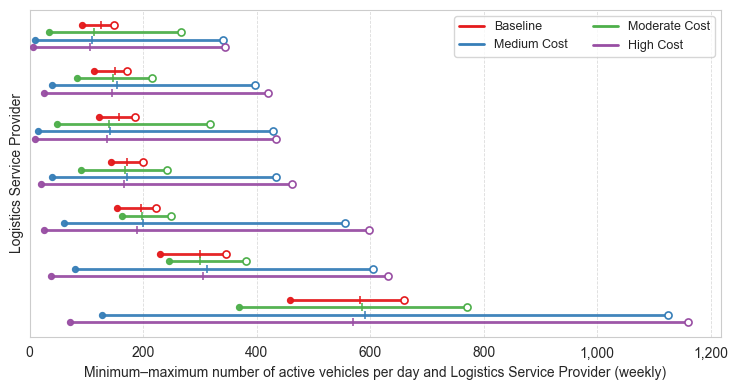

In [89]:
## =============================================================================
# Lollipop per scenario: per-carrier weekly min, mean, and max vehicles (anonymized)
# =============================================================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.lines import Line2D

# --- 1) Prepare scenario, weekday, provider -----------------------------------
work = df_all.copy()

if "scenario" not in work.columns:
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

def _weekday_from_runname(run_name):
    m = re.search(r"_(\d{8})_", str(run_name))
    if not m:
        return None
    dt = datetime.strptime(m.group(1), "%d%m%Y")
    map_en_de = {
        "Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
        "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"
    }
    return map_en_de.get(dt.strftime("%A"))

if "weekday" not in work.columns:
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)

if "provider" not in work.columns:
    raise RuntimeError("Column 'provider' missing in df_all")

weekday_order = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

scenario_display = {
    "basecase":"Baseline",
    "batchmoderate":"Moderate Cost",
    "batchmedium":"Medium Cost",
    "batchhigh":"High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline","Medium Cost","Moderate Cost","High Cost"]

# --- 2) Aggregate per-day vehicle counts --------------------------------------
if "run_name" in work.columns:
    per_run = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday","run_name"], dropna=False)
            .size().reset_index(name="vehicles")
    )
    per_day = (
        per_run.groupby(["scenario_label","provider","weekday"], dropna=False)["vehicles"]
               .max().reset_index()
    )
else:
    per_day = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday"], dropna=False)
            .size().reset_index(name="vehicles")
    )

# --- 3) Weekly min, mean, max per carrier per scenario -------------------------
weekly_stats = (
    per_day.groupby(["scenario_label","provider"], dropna=False)["vehicles"]
           .agg(week_min="min", week_mean="mean", week_max="max")
           .reset_index()
)

# --- 4) Anonymize carriers & determine order -----------------------------------
carriers = weekly_stats["provider"].astype(str).unique().tolist()
car_map = {p: f"LSP {idx:01d}" for idx, p in enumerate(sorted(carriers), start=1)}
weekly_stats["carrier_id"] = weekly_stats["provider"].map(car_map)

order_by_peak = (
    weekly_stats.groupby("carrier_id")["week_max"]
    .max()
    .sort_values(ascending=False)
    .index.tolist()
)

# --- Build full matrix in the exact desired order ---
idx = pd.MultiIndex.from_product([order_by_peak, scenario_order],
                                 names=["carrier_id", "scenario_label"])
plot_df = (
    weekly_stats.set_index(["carrier_id", "scenario_label"])
                .reindex(idx)               # <- respects both orders
                .reset_index()
)


# --- 6) Plot setup -------------------------------------------------------------
sns.set_style("whitegrid")
palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

# Offsets vertically per scenario
# bottom -> top: Baseline, Medium, Moderate, High
offset_map = {
    "Baseline":       0.24,
    "Moderate Cost":  0.08,
    "Medium Cost":   -0.08,
    "High Cost":     -0.24,
}
default_offset = 0.0

# Create figure
fig, ax = plt.subplots(figsize=(7.5, max(4, 0.32*len(order_by_peak))))
y_base = np.arange(len(order_by_peak))
ax.set_yticks(y_base)
ax.set_yticklabels(order_by_peak, fontsize=8)

xmax_global = float(plot_df["week_max"].max()) if plot_df["week_max"].notna().any() else 1.0
ax.set_xlim(0.0, xmax_global * 1.05)

# --- 7) Draw lollipops with mean markers --------------------------------------
for i, scen in enumerate(scenario_order):
    sub = plot_df[plot_df["scenario_label"] == scen].set_index("carrier_id").reindex(order_by_peak)
    c = colors.get(scen, (0.4, 0.4, 0.4))
    y = y_base + offset_map.get(scen, default_offset)

    x_min = sub["week_min"].fillna(0.0).values
    x_max = sub["week_max"].fillna(0.0).values
    x_mean = sub["week_mean"].fillna(0.0).values

    z = 10 + i
    # Lollipop line
    ax.hlines(y=y, xmin=x_min, xmax=x_max, color=c, alpha=0.95, linewidth=2.0, zorder=z)
    # Min marker
    ax.scatter(x_min, y, s=18, color=c, alpha=0.95, zorder=z+1)
    # Max marker (white)
    ax.scatter(x_max, y, s=26, facecolors="white", edgecolors=c, linewidths=1.2, zorder=z+2)
    # Mean marker (small X)
    ax.scatter(x_mean, y, marker="|", s=35, color=c, linewidths=1.1, zorder=z+3)

# --- 8) Formatting ------------------------------------------------------------
ax.set_xlabel("Minimum–maximum number of active vehicles per day and Logistics Service Provider (weekly)", fontsize=10)
ax.set_ylabel("Logistics Service Provider", fontsize=10)
ax.grid(axis="x", linestyle="--", linewidth=0.6, color="0.8", alpha=0.7)
ax.grid(axis="y", linestyle=":", linewidth=0.4, color="0.9", alpha=0.6)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

# Legend in correct order
handles = [
    Line2D([0],[0], color=colors[s], lw=2.0, label=s)
    for s in scenario_order if s in plot_df["scenario_label"].unique()
]
ax.legend(handles=handles, title="", ncols=2, fontsize=9, frameon=True, loc="upper right")

ax.set_yticks([])
ax.set_yticklabels([])
ax.tick_params(axis="y", length=0)


plt.tight_layout()
plt.savefig("lollipop_weekly_min_mean_max_per_carrier_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()




In [11]:
df_all

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name,Cost per Parcel [€/parcel],carrier_category,weekday,weekday_de
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,NaN,NaN,NaN,NaN,NaN,NaN,2.656254,B2B,Monday,Montag
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,NaN,NaN,NaN,NaN,NaN,NaN,4.139754,Mixed,Monday,Montag
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,NaN,NaN,NaN,NaN,NaN,NaN,3.246762,B2B,Monday,Montag
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,NaN,NaN,NaN,NaN,NaN,NaN,2.695286,B2B,Monday,Montag
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,NaN,NaN,NaN,NaN,NaN,NaN,3.574697,Mixed,Monday,Montag
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79269,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,NaN,1873.0,NaN,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,18.844908,0.090909,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Rural with Industrial Influence,12.620688,B2C,Saturday,Samstag
79270,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,NaN,3630.0,NaN,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,34.231393,0.181818,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Urbanized Periphery,6.881250,B2C,Saturday,Samstag
79271,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,NaN,4035.0,NaN,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,4.331356,0.193939,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Rural with Industrial Influence,5.886592,B2C,Saturday,Samstag
79272,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,NaN,1848.0,NaN,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,32.424032,0.090909,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Urbanized Periphery,13.183782,B2C,Saturday,Samstag


In [63]:
# =============================================================================
# Stacked bars: daily driven km per scenario, split into Non-batch vs Batch
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import FuncFormatter

# ---------- 1) Prepare df ----------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]


# weekday (German)
if "weekday" not in work.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        try:
            dt = datetime.strptime(m.group(1), "%d%m%Y")
            map_en_de = {
                "Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
                "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"
            }
            return map_en_de.get(dt.strftime("%A"))
        except Exception:
            return None
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# activity_group (Batch Delivery Day vs Non-batch Delivery Day)
if "activity_group" not in work.columns:
    provider_active_days = {
        "dhl": {"Montag","Mittwoch","Freitag"},
        "hermes": {"Dienstag","Samstag"},
        "dpd": {"Dienstag","Freitag"},
        "gls": {"Montag","Donnerstag"},
        "ups": {"Montag","Donnerstag"},
        "amazon": {"Dienstag","Donnerstag","Samstag"},
        "fedex": {"Montag","Donnerstag"},
    }
    def _is_active(row):
        prov = str(row.get("provider", "")).strip().lower()
        wd = str(row.get("weekday", "")).strip()
        return wd in provider_active_days.get(prov, set())
    work["active_flag"] = work.apply(_is_active, axis=1)
    work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")

    
# --- Force Baseline scenario to "Non-batch Delivery Day" ---
if "scenario" in work.columns and "activity_group" in work.columns:
    work.loc[df["scenario"].str.lower().str.contains("base"), "activity_group"] = "Non-batch Delivery Day"

# KPI column: total km per tour
if "Distance per Tour (km)" in work.columns:
    kpi = "Distance per Tour (km)"
elif "Tour Length (km)" in work.columns:
    work = work.rename(columns={"Tour Length (km)":"Distance per Tour (km)"})
    kpi = "Distance per Tour (km)"
else:
    raise RuntimeError("Neither 'Distance per Tour (km)' nor 'Tour Length (km)' found.")

work[kpi] = pd.to_numeric(work[kpi], errors="coerce")

# Scenario labels and order
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
scen_present = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()]
if not scen_present:
    scen_present = sorted(work["scenario_label"].unique().tolist())

# ---------- 2) Aggregate: daily sums split by activity_group ----------
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday","scenario_label","activity_group"], dropna=False)[kpi]
        .sum()
        .reset_index()
)

# Ensure both stacks exist per day/scenario
all_keys = pd.MultiIndex.from_product([weekday_order, scen_present,
                                       ["Non-batch Delivery Day","Batch Delivery Day"]],
                                      names=["weekday","scenario_label","activity_group"])
daily = daily.set_index(["weekday","scenario_label","activity_group"]).reindex(all_keys).fillna(0.0).reset_index()

# Pivot to columns Batch / Non-batch for stacking
pivot = (
    daily.pivot_table(index=["weekday","scenario_label"], columns="activity_group", values=kpi, aggfunc="sum")
         .reset_index()
         .rename(columns={
             "Non-batch Delivery Day": "Non-batch km",
             "Batch Delivery Day": "Batch km"
         })
)



C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_17948\3850707802.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday","scenario_label","activity_group"], dropna=False)[kpi]


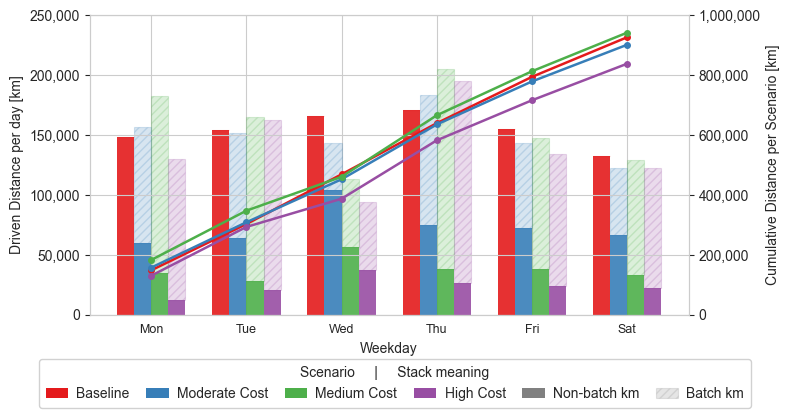

In [60]:

# ---------- 3) Plot ----------
# =============================================================================
# Stacked bars + cumulative line with synchronized y-axes
# =============================================================================

sns.set_style("whitegrid")

palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

fig, ax1 = plt.subplots(figsize=(8, 4))

x_pos = np.arange(len(weekday_order))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Helper for thousands separator
fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)

# ---------- Bars (stacked) ----------
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    nonbatch = sub["Non-batch km"].to_numpy()
    batch = sub["Batch km"].to_numpy()
    xpos = x_pos + (i - (len(scen_present) - 1) / 2.0) * width
    base_col = colors.get(scen, (0.5, 0.5, 0.5))

    ax1.bar(
        xpos, nonbatch, width=width,
        color=base_col, alpha=0.9,
        edgecolor="none"
    )
    ax1.bar(
        xpos, batch, width=width, bottom=nonbatch,
        facecolor=base_col, alpha=0.2,
        hatch=hatch_pattern, edgecolor=base_col, linewidth=edge_lw
    )

# ---------- Second axis (cumulative lines) ----------
ax2 = ax1.twinx()

max_y = 0
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    total = sub["Batch km"] + sub["Non-batch km"]
    cumulative = total.cumsum()
    max_y = max(max_y, cumulative.max())

    ax2.plot(
        x_pos, cumulative,
        color=colors[scen],
        linewidth=1.8,
        marker="o", markersize=4,
        label=f"{scen} cumulative"
    )

from matplotlib.ticker import MaxNLocator, FuncFormatter

# --- 1) Fix axis limits you want ---
# --- 1) Fixed axis limits ---
ax2_min, ax2_max = 0.0, 1_000_000.0     # right axis (cumulative)
ax1_min, ax1_max = 0.0,    250_000.0     # left axis (daily)
ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

# --- 2) Generate “nice” ticks for the right axis ---
nbins = 6
ax2.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
ax2_ticks = ax2.get_yticks()

# --- 3) Map those tick heights to the left axis (so grid lines match) ---
tick_fracs = (ax2_ticks - ax2_min) / (ax2_max - ax2_min)   # 0..1
ax1_ticks = ax1_min + tick_fracs * (ax1_max - ax1_min)
ax1.set_yticks(ax1_ticks)

# --- 4) Formatters ---
fmt = FuncFormatter(lambda v, _: f"{int(v):,}")
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# --- 5) Grid ---
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)

# 5) Formatter beibehalten
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ",")))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ",")))

# Optional: sicherstellen, dass das Grid exakt auf diesen (gemeinsamen) Tickpositionen liegt
ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# --- Achsenbeschriftungen & X-Ticks ---
ax1.set_xlabel("Weekday", fontsize=10)
ax1.set_ylabel("Driven Distance per day [km]", fontsize=10)
ax2.set_ylabel("Cumulative Distance per Scenario [km]", fontsize=10)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels, fontsize=9)

# =========================
# Gemeinsame Legende unten
# =========================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 4 Szenario-Farbflächen
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]

# 2 Stack-Bedeutungen (neutral grau dargestellt)
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch km"),
    Patch(facecolor="gray", alpha=0.20, hatch="////", edgecolor="gray", linewidth=0.8, label="Batch km"),
]

# zu einer Legende kombinieren
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]

leg = fig.legend(
    handles, labels,
    loc="lower center", bbox_to_anchor=(0.5, -0.05),
    ncol=len(handles), frameon=True, fancybox=True, framealpha=0.9,
    title="Scenario     |     Stack meaning",  # kurzer Titel
    handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5
)

# Damit unten Platz ist
plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("distance_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
# =============================================================================
# Compute vehicle counts and total distance by scenario and activity group
# =============================================================================
import pandas as pd
import numpy as np

# Copy base data
# work = df_all.copy()

# Column checks
if "scenario" not in work.columns:
    raise RuntimeError("Column 'scenario' missing in df_all.")
if "activity_group" not in work.columns:
    raise RuntimeError("Column 'activity_group' missing in df_all.")
if "Distance per Tour (km)" not in work.columns and "Tour Length (km)" in work.columns:
    work = work.rename(columns={"Tour Length (km)": "Distance per Tour (km)"})
if "Distance per Tour (km)" not in work.columns:
    raise RuntimeError("No distance column found.")

# Identify vehicle column
vehicle_col = None
for cand in ["vehicle_id", "vehicle", "veh_id"]:
    if cand in work.columns:
        vehicle_col = cand
        break
if not vehicle_col:
    raise RuntimeError("No vehicle ID column found in df_all.")

# Harmonize scenario labels (for readability)
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium": "Medium Cost",
    "batchhigh": "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])

# =============================================================================
# 1) Vehicle count per scenario × activity_group
# =============================================================================
vehicle_counts = (
    work.groupby(["scenario_label", "activity_group"])[vehicle_col]
        .nunique()
        .reset_index(name="Vehicles")
)

# =============================================================================
# 2) Total distance (sum of 'Distance per Tour (km)') per scenario × activity_group
# =============================================================================
distances = (
    work.groupby(["scenario_label", "activity_group"])["Distance per Tour (km)"]
        .sum()
        .reset_index(name="Total_km")
)

# =============================================================================
# 3) Merge and add totals
# =============================================================================
summary = (
    pd.merge(vehicle_counts, distances, on=["scenario_label", "activity_group"], how="outer")
      .fillna(0)
)

# Add per-scenario totals (Batch + Non-batch)
totals = (
    summary.groupby("scenario_label")[["Vehicles", "Total_km"]]
           .sum()
           .reset_index()
           .assign(activity_group="Total")
)
summary = pd.concat([summary, totals], ignore_index=True)

# =============================================================================
# 4) Sort and format
# =============================================================================
summary = summary.sort_values(["scenario_label", "activity_group"], key=lambda s: s.map({
    "Non-batch Delivery Day": 0,
    "Batch Delivery Day": 1,
    "Total": 2
}).fillna(3))

# Pretty formatting
summary["Vehicles"] = summary["Vehicles"].astype(int)
summary["Total_km"] = summary["Total_km"].round(0).astype(int)

# =============================================================================
# 5) Print summary
# =============================================================================
print("\n=== Vehicle count and total driven distance by scenario ===")
for scen in summary["scenario_label"].unique():
    print(f"\nScenario: {scen}")
    sub = summary[summary["scenario_label"] == scen]
    for _, row in sub.iterrows():
        print(f"  {row['activity_group']:20s} | "
              f"Vehicles: {row['Vehicles']:6d} | "
              f"Total km: {row['Total_km']:>10,}")
print("============================================================\n")

# Optional: view as DataFrame
summary




=== Vehicle count and total driven distance by scenario ===

Scenario: Baseline
  Non-batch Delivery Day | Vehicles:   6024 | Total km:    927,238
  Total                | Vehicles:   6024 | Total km:    927,238

Scenario: High Cost
  Non-batch Delivery Day | Vehicles:    737 | Total km:    142,809
  Batch Delivery Day   | Vehicles:   7059 | Total km:    695,971
  Total                | Vehicles:   7796 | Total km:    838,780

Scenario: Medium Cost
  Non-batch Delivery Day | Vehicles:   1174 | Total km:    229,297
  Batch Delivery Day   | Vehicles:   6764 | Total km:    713,335
  Total                | Vehicles:   7938 | Total km:    942,632

Scenario: Moderate Cost
  Non-batch Delivery Day | Vehicles:   3265 | Total km:    443,145
  Batch Delivery Day   | Vehicles:   4476 | Total km:    458,995
  Total                | Vehicles:   7741 | Total km:    902,141



,scenario_label,activity_group,Vehicles,Total_km
0,Baseline,Non-batch Delivery Day,6024,927238
2,High Cost,Non-batch Delivery Day,737,142809
4,Medium Cost,Non-batch Delivery Day,1174,229297
6,Moderate Cost,Non-batch Delivery Day,3265,443145
1,High Cost,Batch Delivery Day,7059,695971
3,Medium Cost,Batch Delivery Day,6764,713335
5,Moderate Cost,Batch Delivery Day,4476,458995
7,Baseline,Total,6024,927238
8,High Cost,Total,7796,838780
9,Medium Cost,Total,7938,942632


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_17948\124967621.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday","scenario_label","activity_group"], dropna=False)


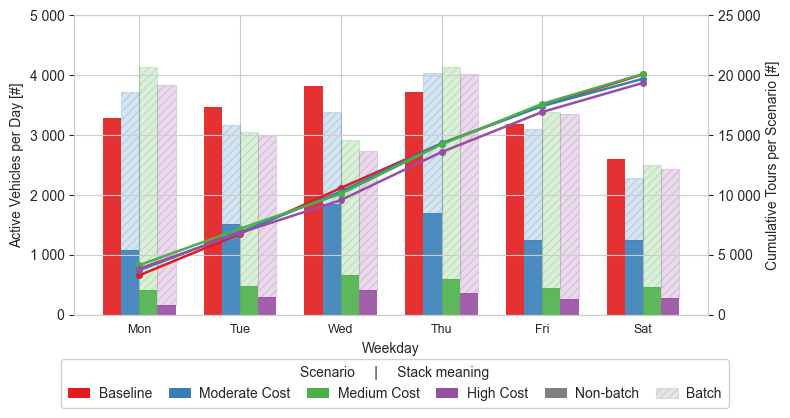


=== Vehicle (tour) count by scenario & activity_group ===
scenario_label         activity_group  # Vehicles (tours)
      Baseline     Batch Delivery Day                   0
      Baseline Non-batch Delivery Day               20079
     High Cost     Batch Delivery Day               17599
     High Cost Non-batch Delivery Day                1768
   Medium Cost     Batch Delivery Day               17045
   Medium Cost Non-batch Delivery Day                3072
 Moderate Cost     Batch Delivery Day               11071
 Moderate Cost Non-batch Delivery Day                8640
      Baseline                  Total               20079
     High Cost                  Total               19367
   Medium Cost                  Total               20117
 Moderate Cost                  Total               19711



In [81]:
# =============================================================================
# Stacked bars: daily vehicle (tour) counts per scenario, split Non-batch/Batch
# + cumulative total tours per scenario (second y-axis, synced ticks)
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.patches import Patch

# ---------- 1) Prepare df (wie im Distanz-Plot) ----------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# weekday (German)
if "weekday" not in work.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        dt = datetime.strptime(m.group(1), "%d%m%Y")
        map_en_de = {"Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
                     "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"}
        return map_en_de.get(dt.strftime("%A"))
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# activity_group (Batch-Day vs Non-batch-Day)
if "activity_group" not in work.columns:
    provider_active_days = {
        "dhl": {"Montag","Mittwoch","Freitag"},
        "hermes": {"Dienstag","Samstag"},
        "dpd": {"Dienstag","Freitag"},
        "gls": {"Montag","Donnerstag"},
        "ups": {"Montag","Donnerstag"},
        "amazon": {"Dienstag","Donnerstag","Samstag"},
        "fedex": {"Montag","Donnerstag"},
    }
    def _is_active(row):
        prov = str(row.get("provider","")).strip().lower()
        wd   = str(row.get("weekday","")).strip()
        return wd in provider_active_days.get(prov, set())
    work["active_flag"]   = work.apply(_is_active, axis=1)
    work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")

# Baseline stets Non-batch
work.loc[work["scenario"].str.lower().str.contains("base"), "activity_group"] = "Non-batch Delivery Day"

# Szenario Labels / Reihenfolge / Farben
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":  "Medium Cost",
    "batchhigh":    "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
scen_present  = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()] or \
                sorted(work["scenario_label"].unique().tolist())

# ---------- 2) Aggregate: tägliche Tour-Anzahlen je activity_group ----------
# Eine Zeile im df = eine Tour → zählen:
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday","scenario_label","activity_group"], dropna=False)
        .size()
        .reset_index(name="tours")
)

# Ensure both stacks per day/scenario
all_keys = pd.MultiIndex.from_product(
    [weekday_order, scen_present, ["Non-batch Delivery Day","Batch Delivery Day"]],
    names=["weekday","scenario_label","activity_group"]
)
daily = (daily.set_index(["weekday","scenario_label","activity_group"])
              .reindex(all_keys).fillna(0).reset_index())

# Pivot zu Spalten „Non-batch tours“ / „Batch tours“
pivot = (
    daily.pivot_table(index=["weekday","scenario_label"], columns="activity_group",
                      values="tours", aggfunc="sum")
         .reset_index()
         .rename(columns={
             "Non-batch Delivery Day": "Non-batch tours",
             "Batch Delivery Day":     "Batch tours"
         })
)

# ---------- 3) Plot ----------
sns.set_style("whitegrid")
palette = sns.color_palette("Set1", len(scenario_order))
colors  = dict(zip(scenario_order, palette))

fig, ax1 = plt.subplots(figsize=(8,4))
x_pos = np.arange(len(weekday_order))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Bars (stacked)
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    nonbatch = sub["Non-batch tours"].to_numpy()
    batch    = sub["Batch tours"].to_numpy()
    xpos     = x_pos + (i - (len(scen_present)-1)/2.0)*width
    base_col = colors.get(scen, (0.5,0.5,0.5))

    ax1.bar(xpos, nonbatch, width=width, color=base_col, alpha=0.9, edgecolor="none")
    ax1.bar(xpos, batch,    width=width, bottom=nonbatch,
            facecolor=base_col, alpha=0.2, hatch=hatch_pattern,
            edgecolor=base_col, linewidth=edge_lw)

# Lines (cumulative total tours per scenario)
ax2   = ax1.twinx()
max_y = 0
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    total = sub["Non-batch tours"] + sub["Batch tours"]
    cum   = total.cumsum()
    max_y = max(max_y, cum.max())
    ax2.plot(x_pos, cum, color=colors[scen], linewidth=1.8, marker="o", markersize=4,
             label=f"{scen} cumulative")

# ---------- 4) Synchronisierte Ticks ----------
# feste Bereiche (pass nötig an deine Größenordnungen an)
ax2_min, ax2_max = 0.0, 25000
ax1_min, ax1_max = 0.0, 5000

ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

# schöne Ticks rechts, links gespiegelt
nbins = 6
ax2.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
ax2_ticks = ax2.get_yticks()
tick_fracs = (ax2_ticks - ax2_min)/(ax2_max - ax2_min)
ax1.set_yticks(ax1_min + tick_fracs*(ax1_max - ax1_min))

fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# Achsen, Labels, X-Ticks
ax1.set_xlabel("Weekday", fontsize=10)
ax1.set_ylabel("Active Vehicles per Day [#]", fontsize=10)
ax2.set_ylabel("Cumulative Tours per Scenario [#]", fontsize=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels, fontsize=9)

ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)

# Gemeinsame Legende unten (Szenarien + Stack-Bedeutung)
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch"),
    Patch(facecolor="gray", alpha=0.20, hatch=hatch_pattern, edgecolor="gray", linewidth=edge_lw, label="Batch"),
]
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=len(handles), frameon=True, fancybox=True, framealpha=0.9,
           title="Scenario     |     Stack meaning",
           handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5)

plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("vehicles_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------- 5) Optional: Summen drucken ----------
totals = (
    daily.assign(tours=lambda d: d["tours"].astype(int))
         .groupby(["scenario_label","activity_group"], dropna=False)["tours"]
         .sum()
         .reset_index()
)
totals_all = totals.groupby("scenario_label", as_index=False)["tours"].sum().assign(activity_group="Total")
print("\n=== Vehicle (tour) count by scenario & activity_group ===")
print(pd.concat([totals, totals_all], ignore_index=True)
        .rename(columns={"tours":"# Vehicles (tours)"}).to_string(index=False))
print("==========================================================\n")


In [70]:
work.groupby("scenario").size()

scenario
basecase         20079
batchhigh        19367
batchmedium      20117
batchmoderate    19711
dtype: int64